[MPC] Real Reactor Temp:       322.2217 K
[MPC] Simulation Reactor Temp: 322.2217 K
[MPC] Mismatch:                0.0000 K
Time 0.00s: Control = 2.00, Temp = 322.22K

[MPC] Real Reactor Temp:       321.3035 K
[MPC] Simulation Reactor Temp: 321.3036 K
[MPC] Mismatch:                0.0001 K
Time 0.10s: Control = 3.00, Temp = 321.30K

[MPC] Real Reactor Temp:       320.4025 K
[MPC] Simulation Reactor Temp: 320.4030 K
[MPC] Mismatch:                0.0004 K
Time 0.20s: Control = 4.00, Temp = 320.40K

[MPC] Real Reactor Temp:       319.5253 K
[MPC] Simulation Reactor Temp: 319.5265 K
[MPC] Mismatch:                0.0012 K
Time 0.30s: Control = 5.00, Temp = 319.53K

[MPC] Real Reactor Temp:       318.6775 K
[MPC] Simulation Reactor Temp: 318.6802 K
[MPC] Mismatch:                0.0028 K
Time 0.40s: Control = 6.00, Temp = 318.68K

[MPC] Real Reactor Temp:       317.8647 K
[MPC] Simulation Reactor Temp: 317.8700 K
[MPC] Mismatch:                0.0053 K
Time 0.50s: Control = 7.00, Temp = 3

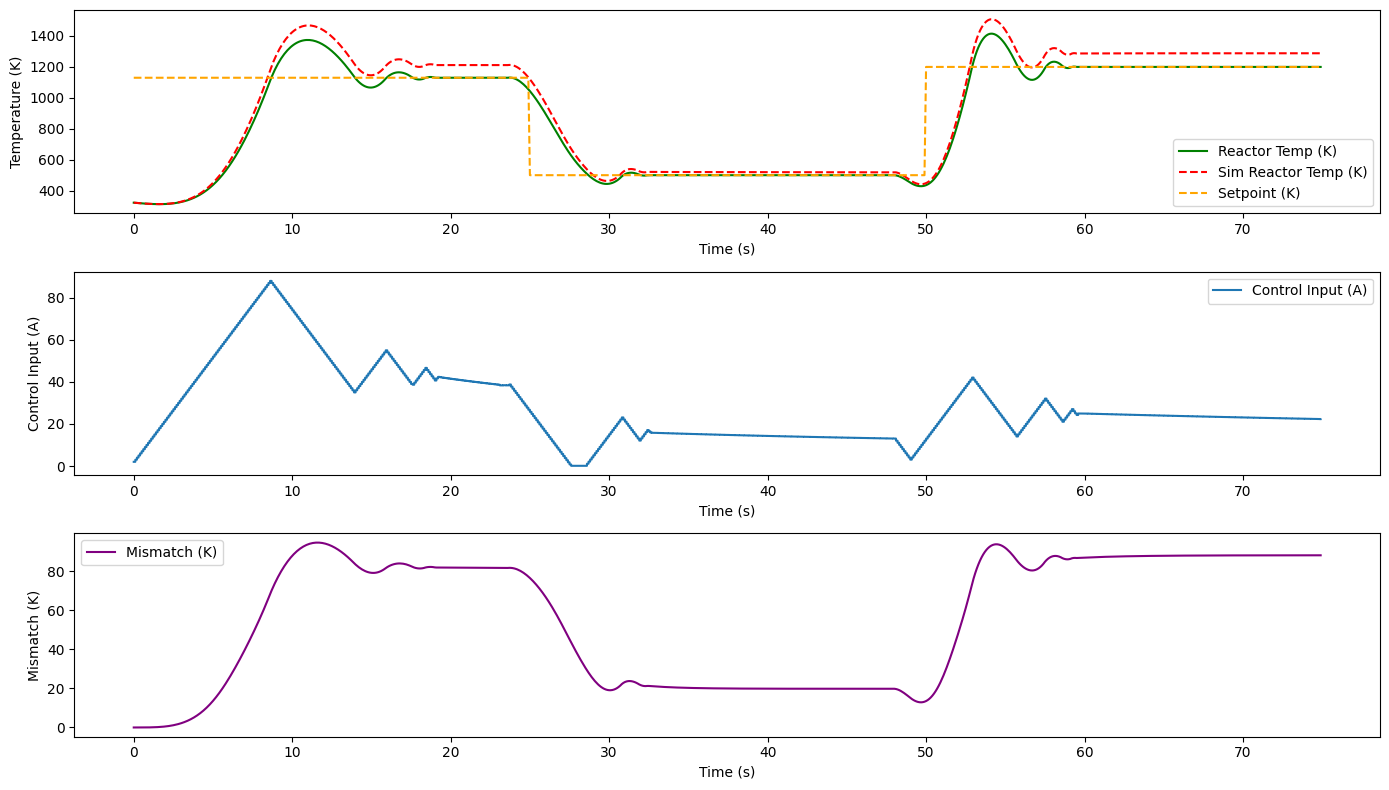

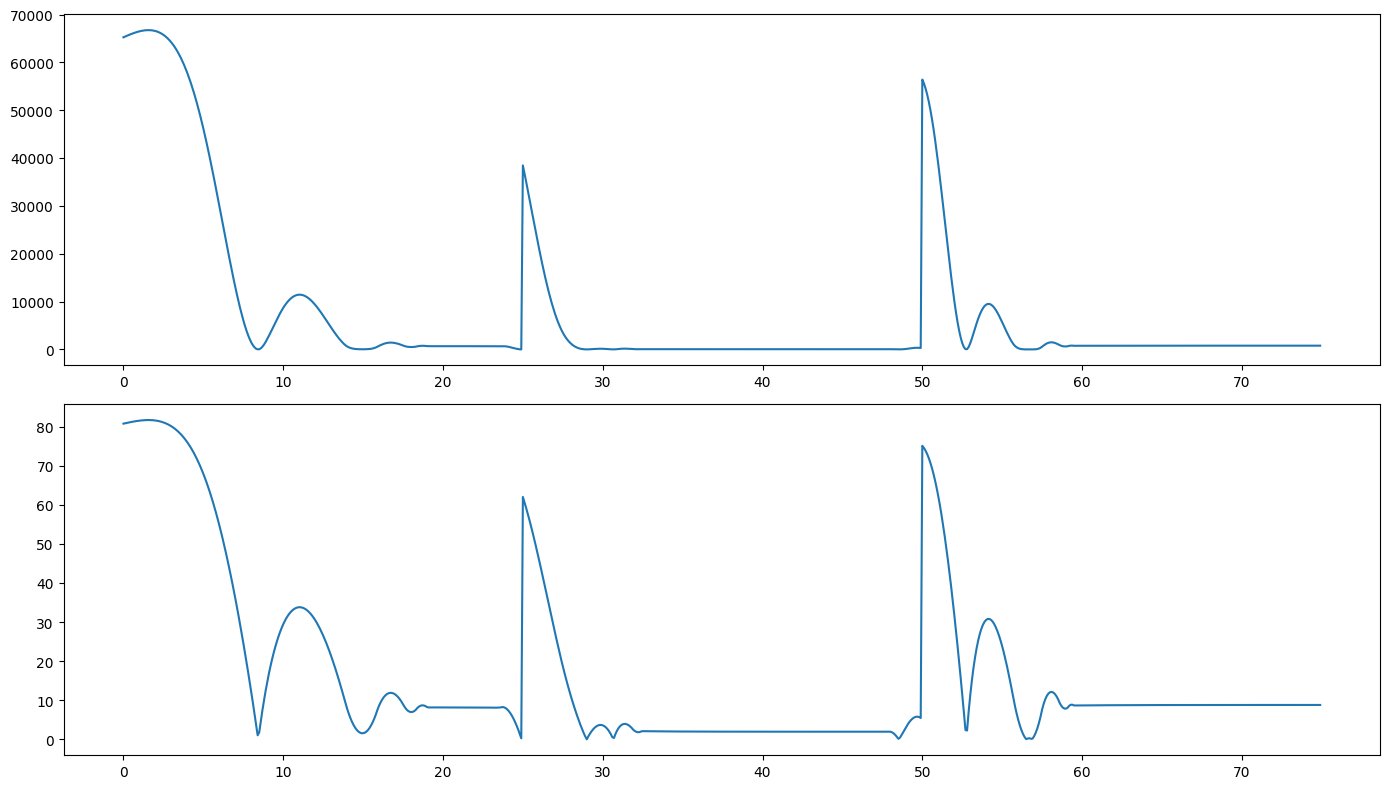

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import openpyxl
import copy
from joblib import load
from scipy.optimize import minimize, differential_evolution # Menggunakan SLSQP dan differential_evolution

# Pastikan modul-modul berikut tersedia di PYTHONPATH Anda:
from Model_def import *          
from Model_constant import *     

# ===================== SIM_REACTOR_MODEL_2 (Incremental Update + Sequence Simulation) =====================
class Sim_Reactor_Model_2:
    def __init__(self, delta_t=1, f_constant=50000):
        self.delta_t = delta_t
        self.f_constant = f_constant
        self.reset_state()
        
    def reset_state(self):
        self.current_index = 0
        self.current_time = 0.0
        self.T_history = [reaction_const.Tin]  # suhu awal
        
        # History untuk logging
        self.times = []
        self.I0_values = []
        self.f_values = []
        self.f_list = []
        self.I_t_values = []
        self.M_t_values = []
        self.H_t_values = []
        self.B_t_values = []
        self.Hys_area_values = []
        self.T_values = []
        self.P_rest_values = []
        self.P_hys_values = []
        self.P_coil_values = []
        self.P_in_values = []
        self.Qin_values = []
        self.Q_flow_in_values = []
        self.Q_flow_out_values = []
        self.Q_wall_out_values = []
        self.Qout_values = []
        self.Qreaction_values = []
        self.sum_mol_cp_values = []
        self.x1_values = []
        self.x2_values = []
        self.x3_values = []
        
    def step(self, new_I0):
        current_time = self.current_time
        self.times.append(current_time)
        current_I0 = new_I0
        self.I0_values.append(current_I0)
        f = self.f_constant
        self.f_values.append(f)
        self.f_list.append(f)
        
        Tin_Tref = reaction_const.Tin - reaction_const.Tref
        Tout_Tref = reaction_const.Tout - reaction_const.Tref
        T_Tref = self.T_history[-1] - reaction_const.Tref
        
        # Perhitungan enthalpi
        dH_CH4, dH_H2O, dH_H2, dH_CO, dH_CO2 = kinetic_param.Enthalpy_i(
            enthalpy_coeff.c_CH4, enthalpy_coeff.c_H2O, enthalpy_coeff.c_H2,
            enthalpy_coeff.c_CO, enthalpy_coeff.c_CO2, T_Tref)
        dH_CH4_in, dH_H2O_in, dH_H2_in, dH_CO_in, dH_CO2_in = heat_stream_in.enthalpy_change_in(
            enthalpy_coeff.c_CH4, enthalpy_coeff.c_H2O, enthalpy_coeff.c_H2,
            enthalpy_coeff.c_CO2, enthalpy_coeff.c_CO2, reaction_const.Tin, reaction_const.Tref)
        
        # Laju reaksi dan kesetimbangan
        k1, k2, k3 = kinetic_param.Reaction_rate(
            reaction_const.A1, reaction_const.A2, reaction_const.A3,
            reaction_const.EA1, reaction_const.EA2, reaction_const.EA3,
            reaction_const.R1, self.T_history[-1])
        K1, K2, K3 = kinetic_param.Equilibrium_c(self.T_history[-1])
        KCH4, KH2O, KCO, KH2 = kinetic_param.Henry_constant_i(
            reaction_const.B_CH4, reaction_const.B_H2O, reaction_const.B_CO,
            reaction_const.B_H2, reaction_const.R1, dH_CH4, dH_H2O, dH_CO, dH_H2,
            self.T_history[-1])
        
        # Aliran panas dan reaksi
        h_outer = heat_wall_out.calculate_h_outer(
            reactor_params.Water_D, reactor_params.Water_v, reactor_params.Water_k,
            reactor_params.Water_Cp, reactor_params.Water_mu, reactor_params.Water_rho, flow_type="laminar")
        dH_CH4_out, dH_H2O_out, dH_H2_out, dH_CO_out, dH_CO2_out = heat_stream_out.enthalpy_change_out(
            enthalpy_coeff.c_CH4, enthalpy_coeff.c_H2O, enthalpy_coeff.c_H2,
            enthalpy_coeff.c_CO, enthalpy_coeff.c_CO2, reaction_const.Tout, reaction_const.Tref)
        nCH4_in, nH2O_in, nH2_in, nCO2_in, nCO_in = mol_stream_in.In_stream(
            initial_cond.nCH4, initial_cond.nH2O, initial_cond.nH2, initial_cond.nCO, initial_cond.nCO2)
        x1, x2, x3 = reaction_kinetic.conversion(current_time, initial_cond.x_Init, initial_cond.x_Fin)
        self.x1_values.append(x1)
        self.x2_values.append(x2)
        self.x3_values.append(x3)
        
        nCH4_r1, nH2O_r1, nH2_r1, nCO_r1 = reaction_kinetic.reaction_1(
            x1, initial_cond.nCH4, initial_cond.nH2O, initial_cond.nH2, initial_cond.nCO)
        nCO_r2, nH2O_r2, nH2_r2, nCO2_r2 = reaction_kinetic.reaction_2(
            x2, nCO_r1, nH2O_r1, nH2_r1, initial_cond.nCO2)
        nCH4_r3, nH2O_r3, nH2_r3, nCO2_r3 = reaction_kinetic.reaction_3(
            x3, initial_cond.nCH4, initial_cond.nH2O, initial_cond.nH2, initial_cond.nCO2)
        nCH4_out, nH2O_out, nH2_out, nCO_out, nCO2_out = mol_stream_out.Out_stream(
            nCH4_r1, nCH4_r3, nH2O_r2, nH2O_r3, nH2_r2, nH2_r3, nCO_r2, nCO2_r2, nCO2_r3)
        sum_mol_cp = (nCH4_in * molecule_weight.WM_CH4 * dH_CH4 +
                      nH2O_in * molecule_weight.WM_H2O * dH_H2O +
                      nH2_in * molecule_weight.WM_H2 * dH_H2 +
                      nCO_in * molecule_weight.WM_CO * dH_CO +
                      nCO2_in * molecule_weight.WM_CO2 * dH_CO2)
        self.sum_mol_cp_values.append(sum_mol_cp)
        
        Q_flow_out = heat_stream_out.Heat_flow_out(
            nCH4_out, nH2O_out, nH2_out, nCO_out, nCO2_out,
            enthalpy_coeff.c_CH4, enthalpy_coeff.c_H2O, enthalpy_coeff.c_H2,
            enthalpy_coeff.c_CO2, enthalpy_coeff.c_CO2, reaction_const.Tout, reaction_const.Tref)
        Qreaction = heat_reaction.HeatReactionTotal(
            heat_reaction.Heat_reaction_1(nCH4_r1, nH2O_r1, nH2_r1, nCO_r1,
                                          dH_CH4, dH_H2O, dH_H2, dH_CO, T_Tref),
            heat_reaction.Heat_reaction_2(nCO_r1, nH2O_r2, nH2_r2, nCO2_r2,
                                          nH2_r1, dH_H2O, dH_H2, dH_CO, dH_CO2, T_Tref),
            heat_reaction.Heat_reaction_3(nCH4_r3, nH2O_r3, nH2_r3, nCO2_r3,
                                          dH_CH4, dH_H2O, dH_H2, dH_CO2, T_Tref))
        Q_wall_out = heat_wall_out.Heat_out(
            self.T_history[-1], reaction_const.Tref, reactor_params.r_quartz_inner,
            reactor_params.r_quartz_outer, reactor_params.k_quartz, reactor_params.k_promasil,
            reactor_params.r_promasil_outer, reactor_params.L, h_outer)
        Q_flow_in = heat_stream_in.Heat_in(
            nCH4_in, nH2O_in, nH2_in, nCO2_in, nCO_in,
            enthalpy_coeff.c_CH4, enthalpy_coeff.c_H2O, enthalpy_coeff.c_H2,
            enthalpy_coeff.c_CO2, enthalpy_coeff.c_CO2, reaction_const.Tin, reaction_const.Tref)
        Qout = Q_flow_out + Q_wall_out
        self.Q_flow_out_values.append(Q_flow_out)
        self.Q_wall_out_values.append(Q_wall_out)
        self.Q_flow_in_values.append(Q_flow_in)
        self.Qout_values.append(Qout)
        self.Qreaction_values.append(Qreaction)
        
        omega = 2 * np.pi * f
        n_substeps = 5
        delta_t_sub = self.delta_t / n_substeps
        hysteresis_area = 0
        I_t_vals = []
        H_t_vals = []
        B_t_vals = []
        for sub_index in range(n_substeps):
            sub_time = current_time + sub_index * delta_t_sub
            I_t = current_I0 * np.sin(omega * sub_time)
            H_t = coil_params.N * I_t / coil_params.h_coil
            B_t = coil_params.mu_0 * coil_params.N * I_t
            I_t_vals.append(I_t)
            H_t_vals.append(H_t)
            B_t_vals.append(B_t)
            hysteresis_area = simpson(H_t_vals, B_t_vals)
        self.I_t_values.append(I_t_vals[-1])
        self.H_t_values.append(H_t_vals[-1])
        self.B_t_values.append(B_t_vals[-1])
        self.M_t_values.append(coil_params.Ms * (
            (((2 * coil_params.J + 1) / (2 * coil_params.J)) *
             (np.cosh(((2 * coil_params.J + 1) / (2 * coil_params.J)) * (I_t_vals[-1])) /
              (np.sinh(((2 * coil_params.J + 1) / (2 * coil_params.J)) * (I_t_vals[-1]) + 1e-10))) -
             (1 / (2 * coil_params.J)) * (np.cosh(I_t_vals[-1] / (2 * coil_params.J)) /
              (np.sinh(I_t_vals[-1] / (2 * coil_params.J)) + 1e-10)))
        ))
        self.Hys_area_values.append(hysteresis_area)
        
        P_hys = hysteresis_area * f * coil_params.ms
        self.P_hys_values.append(P_hys)
        I_rms = current_I0 / np.sqrt(2)
        self.P_coil_values.append(I_rms ** 2 * coil_params.L_coil * (np.pi * coil_params.r0 / coil_params.A_coil) *
                                   np.sqrt(coil_params.N * np.sqrt(np.pi) * coil_params.r0 *
                                           coil_params.rho_copper * coil_params.miu_copper / coil_params.h_coil) *
                                   np.sqrt(f))
        P_coil = self.P_coil_values[-1]
        P_in_temp = P_hys + P_coil
        P_rest = 0.05 * P_in_temp
        self.P_rest_values.append(P_rest)
        P_in = (P_hys + P_coil + P_rest) * 1.1  #------------- sim at 10% better condition then real reactor or real reactor less 10% performance then ideal reactor (sim reactor)
        self.P_in_values.append(P_in)
        Qin = P_in * current_time
        self.Qin_values.append(Qin)
        
        dT_dt = (Q_flow_in + Qin - Qreaction - Q_flow_out - Q_wall_out) / sum_mol_cp
        new_T = self.T_history[-1] + dT_dt * self.delta_t
        self.T_history.append(new_T)
        self.T_values.append(new_T)
        
        self.current_index += 1
        self.current_time += self.delta_t
        
        return {'Time (s)': current_time,
                'I0_control (A)': current_I0,
                'dT/dt (K/s)': dT_dt,
                'Temperature (K)': new_T}
    
    def simulate_sequence(self, control_sequence):
        self.reset_state()
        outputs = []
        for u in control_sequence:
            out = self.step(u)
            outputs.append(out)
        return outputs


# ===================== REAL_REACTOR_MODEL_1 (Incremental Update + Sequence Simulation) =====================
class Real_Reactor_Model_1:
    def __init__(self, delta_t=1, f_constant=50000):
        self.delta_t = delta_t
        self.f_constant = f_constant
        self.reset_state()
        
    def reset_state(self):
        self.current_index = 0
        self.current_time = 0.0
        self.T_history = [reaction_const.Tin]  # suhu awal
        
        # History untuk logging
        self.times = []
        self.I0_values = []
        self.f_values = []
        self.f_list = []
        self.I_t_values = []
        self.M_t_values = []
        self.H_t_values = []
        self.B_t_values = []
        self.Hys_area_values = []
        self.T_values = []
        self.P_rest_values = []
        self.P_hys_values = []
        self.P_coil_values = []
        self.P_in_values = []
        self.Qin_values = []
        self.Q_flow_in_values = []
        self.Q_flow_out_values = []
        self.Q_wall_out_values = []
        self.Qout_values = []
        self.Qreaction_values = []
        self.sum_mol_cp_values = []
        self.x1_values = []
        self.x2_values = []
        self.x3_values = []
        
    def step(self, new_I0):
        current_time = self.current_time
        self.times.append(current_time)
        current_I0 = new_I0
        self.I0_values.append(current_I0)
        f = self.f_constant
        self.f_values.append(f)
        self.f_list.append(f)
        
        Tin_Tref = reaction_const.Tin - reaction_const.Tref
        Tout_Tref = reaction_const.Tout - reaction_const.Tref
        T_Tref = self.T_history[-1] - reaction_const.Tref
        
        # Perhitungan enthalpi
        dH_CH4, dH_H2O, dH_H2, dH_CO, dH_CO2 = kinetic_param.Enthalpy_i(
            enthalpy_coeff.c_CH4, enthalpy_coeff.c_H2O, enthalpy_coeff.c_H2,
            enthalpy_coeff.c_CO, enthalpy_coeff.c_CO2, T_Tref)
        dH_CH4_in, dH_H2O_in, dH_H2_in, dH_CO_in, dH_CO2_in = heat_stream_in.enthalpy_change_in(
            enthalpy_coeff.c_CH4, enthalpy_coeff.c_H2O, enthalpy_coeff.c_H2,
            enthalpy_coeff.c_CO2, enthalpy_coeff.c_CO2, reaction_const.Tin, reaction_const.Tref)
        
        # Laju reaksi dan kesetimbangan
        k1, k2, k3 = kinetic_param.Reaction_rate(
            reaction_const.A1, reaction_const.A2, reaction_const.A3,
            reaction_const.EA1, reaction_const.EA2, reaction_const.EA3,
            reaction_const.R1, self.T_history[-1])
        K1, K2, K3 = kinetic_param.Equilibrium_c(self.T_history[-1])
        KCH4, KH2O, KCO, KH2 = kinetic_param.Henry_constant_i(
            reaction_const.B_CH4, reaction_const.B_H2O, reaction_const.B_CO,
            reaction_const.B_H2, reaction_const.R1, dH_CH4, dH_H2O, dH_CO, dH_H2,
            self.T_history[-1])
        
        # Aliran panas dan reaksi
        h_outer = heat_wall_out.calculate_h_outer(
            reactor_params.Water_D, reactor_params.Water_v, reactor_params.Water_k,
            reactor_params.Water_Cp, reactor_params.Water_mu, reactor_params.Water_rho, flow_type="laminar")
        dH_CH4_out, dH_H2O_out, dH_H2_out, dH_CO_out, dH_CO2_out = heat_stream_out.enthalpy_change_out(
            enthalpy_coeff.c_CH4, enthalpy_coeff.c_H2O, enthalpy_coeff.c_H2,
            enthalpy_coeff.c_CO, enthalpy_coeff.c_CO2, reaction_const.Tout, reaction_const.Tref)
        nCH4_in, nH2O_in, nH2_in, nCO2_in, nCO_in = mol_stream_in.In_stream(
            initial_cond.nCH4, initial_cond.nH2O, initial_cond.nH2, initial_cond.nCO, initial_cond.nCO2)
        x1, x2, x3 = reaction_kinetic.conversion(current_time, initial_cond.x_Init, initial_cond.x_Fin)
        self.x1_values.append(x1)
        self.x2_values.append(x2)
        self.x3_values.append(x3)
        
        nCH4_r1, nH2O_r1, nH2_r1, nCO_r1 = reaction_kinetic.reaction_1(
            x1, initial_cond.nCH4, initial_cond.nH2O, initial_cond.nH2, initial_cond.nCO)
        nCO_r2, nH2O_r2, nH2_r2, nCO2_r2 = reaction_kinetic.reaction_2(
            x2, nCO_r1, nH2O_r1, nH2_r1, initial_cond.nCO2)
        nCH4_r3, nH2O_r3, nH2_r3, nCO2_r3 = reaction_kinetic.reaction_3(
            x3, initial_cond.nCH4, initial_cond.nH2O, initial_cond.nH2, initial_cond.nCO2)
        nCH4_out, nH2O_out, nH2_out, nCO_out, nCO2_out = mol_stream_out.Out_stream(
            nCH4_r1, nCH4_r3, nH2O_r2, nH2O_r3, nH2_r2, nH2_r3, nCO_r2, nCO2_r2, nCO2_r3)
        sum_mol_cp = (nCH4_in * molecule_weight.WM_CH4 * dH_CH4 +
                      nH2O_in * molecule_weight.WM_H2O * dH_H2O +
                      nH2_in * molecule_weight.WM_H2 * dH_H2 +
                      nCO_in * molecule_weight.WM_CO * dH_CO +
                      nCO2_in * molecule_weight.WM_CO2 * dH_CO2)
        self.sum_mol_cp_values.append(sum_mol_cp)
        
        Q_flow_out = heat_stream_out.Heat_flow_out(
            nCH4_out, nH2O_out, nH2_out, nCO_out, nCO2_out,
            enthalpy_coeff.c_CH4, enthalpy_coeff.c_H2O, enthalpy_coeff.c_H2,
            enthalpy_coeff.c_CO2, enthalpy_coeff.c_CO2, reaction_const.Tout, reaction_const.Tref)
        Qreaction = heat_reaction.HeatReactionTotal(
            heat_reaction.Heat_reaction_1(nCH4_r1, nH2O_r1, nH2_r1, nCO_r1,
                                          dH_CH4, dH_H2O, dH_H2, dH_CO, T_Tref),
            heat_reaction.Heat_reaction_2(nCO_r1, nH2O_r2, nH2_r2, nCO2_r2,
                                          nH2_r1, dH_H2O, dH_H2, dH_CO, dH_CO2, T_Tref),
            heat_reaction.Heat_reaction_3(nCH4_r3, nH2O_r3, nH2_r3, nCO2_r3,
                                          dH_CH4, dH_H2O, dH_H2, dH_CO2, T_Tref))
        Q_wall_out = heat_wall_out.Heat_out(
            self.T_history[-1], reaction_const.Tref, reactor_params.r_quartz_inner,
            reactor_params.r_quartz_outer, reactor_params.k_quartz, reactor_params.k_promasil,
            reactor_params.r_promasil_outer, reactor_params.L, h_outer)
        Q_flow_in = heat_stream_in.Heat_in(
            nCH4_in, nH2O_in, nH2_in, nCO2_in, nCO_in,
            enthalpy_coeff.c_CH4, enthalpy_coeff.c_H2O, enthalpy_coeff.c_H2,
            enthalpy_coeff.c_CO2, enthalpy_coeff.c_CO2, reaction_const.Tin, reaction_const.Tref)
        Qout = Q_flow_out + Q_wall_out
        self.Q_flow_out_values.append(Q_flow_out)
        self.Q_wall_out_values.append(Q_wall_out)
        self.Q_flow_in_values.append(Q_flow_in)
        self.Qout_values.append(Qout)
        self.Qreaction_values.append(Qreaction)
        
        omega = 2 * np.pi * f
        n_substeps = 5
        delta_t_sub = self.delta_t / n_substeps
        hysteresis_area = 0
        I_t_vals = []
        H_t_vals = []
        B_t_vals = []
        for sub_index in range(n_substeps):
            sub_time = current_time + sub_index * delta_t_sub
            I_t = current_I0 * np.sin(omega * sub_time)
            H_t = coil_params.N * I_t / coil_params.h_coil
            B_t = coil_params.mu_0 * coil_params.N * I_t
            I_t_vals.append(I_t)
            H_t_vals.append(H_t)
            B_t_vals.append(B_t)
            hysteresis_area = simpson(H_t_vals, B_t_vals)
        self.I_t_values.append(I_t_vals[-1])
        self.H_t_values.append(H_t_vals[-1])
        self.B_t_values.append(B_t_vals[-1])
        self.M_t_values.append(coil_params.Ms * (
            (((2 * coil_params.J + 1) / (2 * coil_params.J)) *
             (np.cosh(((2 * coil_params.J + 1) / (2 * coil_params.J)) * (I_t_vals[-1])) /
              (np.sinh(((2 * coil_params.J + 1) / (2 * coil_params.J)) * (I_t_vals[-1]) + 1e-10))) -
             (1 / (2 * coil_params.J)) * (np.cosh(I_t_vals[-1] / (2 * coil_params.J)) /
              (np.sinh(I_t_vals[-1] / (2 * coil_params.J)) + 1e-10)))
        ))
        self.Hys_area_values.append(hysteresis_area)
        
        P_hys = hysteresis_area * f * coil_params.ms
        self.P_hys_values.append(P_hys)
        I_rms = current_I0 / np.sqrt(2)
        self.P_coil_values.append(I_rms ** 2 * coil_params.L_coil * (np.pi * coil_params.r0 / coil_params.A_coil) *
                                   np.sqrt(coil_params.N * np.sqrt(np.pi) * coil_params.r0 *
                                           coil_params.rho_copper * coil_params.miu_copper / coil_params.h_coil) *
                                   np.sqrt(f))
        P_coil = self.P_coil_values[-1]
        P_in_temp = P_hys + P_coil
        P_rest = 0.05 * P_in_temp
        self.P_rest_values.append(P_rest)
        P_in = (P_hys + P_coil + P_rest)
        self.P_in_values.append(P_in)
        Qin = P_in * current_time
        self.Qin_values.append(Qin)
        
        dT_dt = (Q_flow_in + Qin - Qreaction - Q_flow_out - Q_wall_out) / sum_mol_cp
        new_T = self.T_history[-1] + dT_dt * self.delta_t
        self.T_history.append(new_T)
        self.T_values.append(new_T)
        
        self.current_index += 1
        self.current_time += self.delta_t
        
        return {'Time (s)': current_time,
                'I0_control (A)': current_I0,
                'dT/dt (K/s)': dT_dt,
                'Temperature (K)': new_T}
    
    def simulate_sequence(self, control_sequence):
        self.reset_state()
        outputs = []
        for u in control_sequence:
            out = self.step(u)
            outputs.append(out)
        return outputs


class ReactorMPC:
    def __init__(self, config):
        self.control_sequence = list(config['initial_control_sequence'])
        self.setpoint = config['setpoint']
        self.delta_t = config['delta_t']
        self.delta_u_max = config['delta_u_max']
        self.u_min = config['u_min']
        self.u_max = config['u_max']
        self.R_weight = config['R_weight']
        self.Q_weight = config['Q_weight']
        self.optimizer = config['optimizer']
        self.M = config['M']  # Horizon for prediction
        self.N = config['N']  # Horizon for control input optimization
        self.switch_interval = None
        self.max_steps = config['max_steps']
        self.ISE_values = [0]  # Integral Squared Error
        self.IAE_values = [0]  # Integral Absolute Error
        self.error_history = []  # List to store error history at each time step
        self.mismatch_history = []  # List to store mismatch history
        self.reactor_model = Sim_Reactor_Model_2(delta_t=self.delta_t)  # Simulation reactor
        self.real_reactor_model = Real_Reactor_Model_1(delta_t=self.delta_t)  # Real reactor
        self.u_prev = self.control_sequence[-1]
        self.real_reactor_temp_history = []

        if self.switch_interval is None:
            if self.max_steps is None:
                raise ValueError("Either max_steps or switch_interval must be provided.")
            total_time = self.max_steps * self.delta_t
            self.switch_interval = total_time / len(self.setpoint)

    def get_setpoint(self, t):
        """Determine which setpoint is active based on time t."""
        index = int(t // self.switch_interval)
        if index >= len(self.setpoint):
            return self.setpoint[-1]
        return self.setpoint[index]

    def simulate_horizon(self, u_seq):
        """Simulate the horizon given a sequence of control inputs."""
        backup = copy.deepcopy(self.real_reactor_model)  # Backup reactor model state
        errors = []
        for m in range(self.M):
            u_m = u_seq[m] if m < len(u_seq) else u_seq[-1]
            out = self.real_reactor_model.step(u_m)
            pred_temp = out['Temperature (K)'] #we need simulation to predict the temperature
            pred_time = out['Time (s)']
            current_setpoint = self.get_setpoint(pred_time)
            error = pred_temp - current_setpoint
            errors.append(error)

            # Update ISE and IAE
            self.ISE_values.append(error ** 2 * self.delta_t)
            self.IAE_values.append(abs(error) * self.delta_t)

        self.error_history.append(errors)
        self.real_reactor_model = backup  # Restore model state
        return errors

    def cost_function(self, u):
        """Calculate the cost for the optimization problem."""
        u_seq = u  # Candidate future control moves (length N)
        errors = self.simulate_horizon(u_seq)

        # Tracking cost: sum of squared errors weighted by Q_weight
        tracking_cost = self.Q_weight * np.sum(np.array(errors) ** 2)

        # Control move cost: penalizing large changes in control input
        control_moves = np.array([u_seq[0] - self.u_prev] + [u_seq[i] - u_seq[i - 1] for i in range(1, self.N)])
        R = self.R_weight * np.eye(self.N)
        control_cost = control_moves.T @ R @ control_moves

        return tracking_cost + control_cost

    def constraint1(self, u):
        """Enforce: u[0] - u_prev <= delta_u_max"""
        return self.delta_u_max - (u[0] - self.u_prev)

    def constraint2(self, u):
        """Enforce: u_prev - u[0] <= delta_u_max"""
        return self.delta_u_max - (self.u_prev - u[0])

    def solve_de(self):
        """Solve using differential evolution optimization."""
        bounds = [(self.u_min, self.u_max)] * self.N
        result = differential_evolution(lambda x: self.cost_function(x), bounds)
        return result.x

    def solve(self, config):
        """Solve the optimization problem using SLSQP or DE."""
        bounds = [(self.u_min, self.u_max)] * self.N
        cons = [{'type': 'ineq', 'fun': self.constraint1},
                {'type': 'ineq', 'fun': self.constraint2}]
        x0 = np.array([self.u_prev] * self.N)
        if config['optimizer'] == 'de':
            return self.solve_de()
        else:
            res = minimize(self.cost_function, x0, method='SLSQP', bounds=bounds, constraints=cons)
            return res.x if res.success else x0

    def update(self):
        """Update MPC: compute the optimal control, apply it to the real reactor, and return the result."""
        u_seq_opt = self.solve(config)
        self.control_sequence.append(u_seq_opt[0])  # Append the first control move
        self.u_prev = u_seq_opt[0]

        real_out = self.real_reactor_model.step(u_seq_opt[0])           
        real_temp = real_out['Temperature (K)']                      
        self.real_reactor_temp_history.append(real_temp)

        # Apply to the real reactor for one step
        out = self.reactor_model.step(u_seq_opt[0])

        sim_temp = out['Temperature (K)']
        mismatch = abs(real_temp - sim_temp)         
        self.mismatch_history.append(mismatch)     

        print(f"[MPC] Real Reactor Temp:       {real_temp:.4f} K")
        print(f"[MPC] Simulation Reactor Temp: {sim_temp:.4f} K")
        print(f"[MPC] Mismatch:                {mismatch:.4f} K")

        return out


if __name__ == "__main__":
    # Configuration parameters for MPC
    config = {
        'initial_control_sequence': [1], # I current (Ampere)
        'setpoint': [1130, 500, 1200],
        'delta_t': 0.1,
        'delta_u_max': 1,
        'u_min': 0.1,
        'u_max': 130,
        'R_weight': 0.001,
        'Q_weight': 0.01,
        'optimizer': 'slsqp',  # 'slsqp' or 'de'
        'M': 20,
        'N': 5,
        'max_steps': 750,
        'plot_file_path_control': r"D:\Python-Github-Projects\Model\MPC_Sim_reactor_Control_Plot.png",
        'plot_file_path_error': r"D:\Python-Github-Projects\Model\MPC_Sim_reactor_Error_Plot.png"
    }

    # Instantiate the MPC controller
    reactor_mpc = ReactorMPC(config)

    # Initialize histories for plotting and analysis
    reactor_temp_history = []
    reactor_control_history = []
    reactor_time_steps = []
    setpoint_history = []
    real_reactor_temp_history = []
    ISE_history = []
    IAE_history = []
    mismatch_history = []

    while len(reactor_temp_history) < config['max_steps']:
        reactor_state = reactor_mpc.update()
        reactor_temp = reactor_state['Temperature (K)']
        current_time = reactor_state['Time (s)']
        reactor_temp_history.append(reactor_temp)
        reactor_control_history.append(reactor_mpc.u_prev)
        reactor_time_steps.append(current_time)
        current_setpoint = reactor_mpc.get_setpoint(current_time)
        setpoint_history.append(current_setpoint)
        real_reactor_temp_history.append(reactor_mpc.real_reactor_temp_history[-1]) 
        mismatch_history.append(reactor_mpc.mismatch_history[-1])

        error = reactor_temp - setpoint_history[-1]
        if len(ISE_history) == 0:
            ISE_history.append(error ** 2 * config['delta_t'])
            IAE_history.append(abs(error) * config['delta_t'])
        else:
            ISE_history.append(error ** 2 * config['delta_t'])
            IAE_history.append(abs(error) * config['delta_t'])

        print(f"Time {current_time:.2f}s: Control = {reactor_mpc.u_prev:.2f}, Temp = {reactor_temp:.2f}K")
        print(f"")

    # DataFrame to store results
    df_results = pd.DataFrame({
        'Time (s)': reactor_time_steps,
        'I0_control (A)': reactor_control_history,
        'Temperature (K)': real_reactor_temp_history,
        'Sim Temperature (K)': reactor_temp_history,
        'Setpoint (K)': setpoint_history,
        'ISE': ISE_history,
        'IAE': IAE_history,
        'Mismatch (K)': mismatch_history
    })

    # Menyimpan DataFrame ke file Excel dengan sheet name "MPC_Sim_Reactor"
    # Save DataFrames to Excel for new Files --------------------------------- 1 step
    file_path = r"D:\Python-Github-Projects\Model\MPC Control Result 17N.xlsx"
    with pd.ExcelWriter(file_path) as writer:
        df_results.to_excel(writer, sheet_name='MPC_Reactor_17N_01', index=False)
    
    # Save DataFrames to Excel in the same file with different sheet --------- 2 step forward
    #with pd.ExcelWriter(file_path, engine='openpyxl', mode='a', if_sheet_exists='new') as writer:
    #   df_results.to_excel(writer, sheet_name='MPC_Sim_Reactor_17N_04', index=False)
    
    #print(f"Simulation results saved to {file_path}")

    # Plot results
    plt.figure(figsize=(14, 8))
    plt.subplot(3, 1, 1)
    plt.plot(reactor_time_steps, real_reactor_temp_history, label="Reactor Temp (K)", color="green", linestyle='-')
    plt.plot(reactor_time_steps, reactor_temp_history, label="Sim Reactor Temp (K)", color="red", linestyle='--')
    plt.plot(reactor_time_steps, setpoint_history, label="Setpoint (K)", color="orange", linestyle='--')
    plt.xlabel("Time (s)")
    plt.ylabel("Temperature (K)")
    plt.legend()

    plt.subplot(3, 1, 2)
    plt.step(reactor_time_steps, reactor_control_history, label="Control Input (A)", where='post')
    plt.xlabel("Time (s)")
    plt.ylabel("Control Input (A)")
    plt.legend()

    plt.subplot(3, 1, 3)
    plt.plot(reactor_time_steps, mismatch_history, label="Mismatch (K)", color='purple')
    plt.xlabel("Time (s)")
    plt.ylabel("Mismatch (K)")
    plt.legend()

    plt.tight_layout()
    plt.savefig(config['plot_file_path_control'])
    plt.show()

    plt.figure(figsize=(14, 8))
    plt.subplot(2, 1, 1)
    plt.plot(reactor_time_steps, ISE_history, label="ISE (Integral Square Error)")
    plt.subplot(2, 1, 2)
    plt.plot(reactor_time_steps, IAE_history, label="IAE (Integral Absolute Error)")
    plt.tight_layout()
    plt.savefig(config['plot_file_path_error'])
    plt.show()


In [6]:
import pandas as pd

# Step 1: Initialize result dictionary
data = {}

# Step 2: Create dataset with lagged features
excel_file = r"D:\Python-Github-Projects\Model\MPC Control Result 17N.xlsx"
sheet_name = 'MPC_Reactor_17N_01'

# Read the specified sheet
df = pd.read_excel(excel_file, sheet_name=sheet_name)

# If your real sheet has slightly different names, adjust accordingly.
time_col = 'Time (s)'
input_col = 'I0_control (A)'
output_col = 'Temperature (K)'

# Keep the columns in one DataFrame so "Time (s)" is not lost
# We do NOT reset the index; we keep the sheet's row numbering and the Time (s) column
data_df = df[[time_col, input_col, output_col]].copy()

# Just to be consistent, let's rename them to the same string, but
# typically you'd leave them if they're already correct.
# Or if you don't want to rename, you can skip this step.
data_df.rename(
    columns={
        time_col: 'Time (s)',
        input_col: 'I0_control (A)',
        output_col: 'Temperature (K)'
    },
    inplace=True
)

# Decide on the maximum lag you want
t_max = 1


def create_lagged_features_fillna(df, input_col, output_col, t_max, fill_value=0):
    """
    Create lagged features for input and output columns while
    preserving the original "Time (s)" column. Fill initial NaNs with fill_value.
    """
    # We will modify a copy to avoid altering the original DataFrame
    df_lagged = df.copy()

    # Create lagged input features
    for lag in range(t_max + 1):
        df_lagged[f'k-{lag} I0_control (A)'] = df_lagged[input_col].shift(lag)

    # Create lagged output features
    for lag in range(t_max + 1):
        df_lagged[f'k-{lag} Temperature (K)'] = df_lagged[output_col].shift(lag)

    # Fill the NaN values created by .shift() with zero or another fill_value
    columns_to_fill = [f'k-{lag} I0_control (A)' for lag in range(t_max + 1)]
    columns_to_fill += [f'k-{lag} Temperature (K)' for lag in range(t_max + 1)]
    df_lagged[columns_to_fill] = df_lagged[columns_to_fill].fillna(fill_value)

    return df_lagged


# Apply the function to create a lagged dataset
lagged_data = create_lagged_features_fillna(
    data_df,
    'I0_control (A)',
    'Temperature (K)',
    t_max=t_max,
    fill_value=0
)

# Step 3: Print the generated data as a dictionary
# This conversion keeps "Time (s)" as a key in every record
data = lagged_data.to_dict(orient='records')
print("Generated Data (first 10 rows):")
for record in data[:10]:
    print(record)

# Step 4: (Optional) Save the DataFrame to a new Excel file
# Uncomment below if you want to save to a new file
# file_path = 'mass_energy_balance_magnetic_induction_dataset_117N.xlsx'
# with pd.ExcelWriter(file_path) as writer:
#     lagged_data.to_excel(writer, sheet_name='133A', index=False)
# print(f"Lagged dataset has been saved to {file_path} successfully.")

# -----------------------------------------
# Or save in the same file but in a new sheet
file_path = r"D:\Python-Github-Projects\Model\MPC Control Result 17N.xlsx"
with pd.ExcelWriter(file_path, engine='openpyxl', mode='a', if_sheet_exists='new') as writer:
    lagged_data.to_excel(writer, sheet_name='Lagged_MPC_Reactor_17N_01', index=False)

print(f"Lagged dataset has been appended to {file_path} successfully.")


Generated Data (first 10 rows):
{'Time (s)': 0.0, 'I0_control (A)': 2.000001277130444, 'Temperature (K)': 322.2216794658713, 'k-0 I0_control (A)': 2.000001277130444, 'k-1 I0_control (A)': 0.0, 'k-0 Temperature (K)': 322.2216794658713, 'k-1 Temperature (K)': 0.0}
{'Time (s)': 0.1, 'I0_control (A)': 3.000001277170414, 'Temperature (K)': 321.3034901757462, 'k-0 I0_control (A)': 3.000001277170414, 'k-1 I0_control (A)': 2.000001277130444, 'k-0 Temperature (K)': 321.3034901757462, 'k-1 Temperature (K)': 322.2216794658713}
{'Time (s)': 0.2, 'I0_control (A)': 4.000001290496434, 'Temperature (K)': 320.4025459505651, 'k-0 I0_control (A)': 4.000001290496434, 'k-1 I0_control (A)': 3.000001277170414, 'k-0 Temperature (K)': 320.4025459505651, 'k-1 Temperature (K)': 321.3034901757462}
{'Time (s)': 0.3, 'I0_control (A)': 5.000001290733166, 'Temperature (K)': 319.5252543936804, 'k-0 I0_control (A)': 5.000001290733166, 'k-1 I0_control (A)': 4.000001290496434, 'k-0 Temperature (K)': 319.5252543936804, 'k

Computed setpoint schedule: [{'start': 1, 'end': 250, 'setpoint': 1130}, {'start': 251, 'end': 500, 'setpoint': 500}, {'start': 501, 'end': 750, 'setpoint': 1200}]
Input scaler saved to: D:\Python-Github-Projects\Model\4_input_MPC_scaler_X.pkl
Output scaler saved to: D:\Python-Github-Projects\Model\4_input_MPC_scaler_y.pkl
ESN training completed with output feedback = True
ESN Training Time: 0.04 sec, Throughput: 11950.49 samples/sec
Epoch 1/60
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5182 - val_loss: 0.4631
Epoch 2/60
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1552 - val_loss: 0.0038
Epoch 3/60
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0094 - val_loss: 0.0067
Epoch 4/60
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0054 - val_loss: 4.6559e-05
Epoch 5/60
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0042 - val_loss: 0.0105
Epoch 6/60
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0051 - val_loss: 0.0029
Epoch 7/60
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s

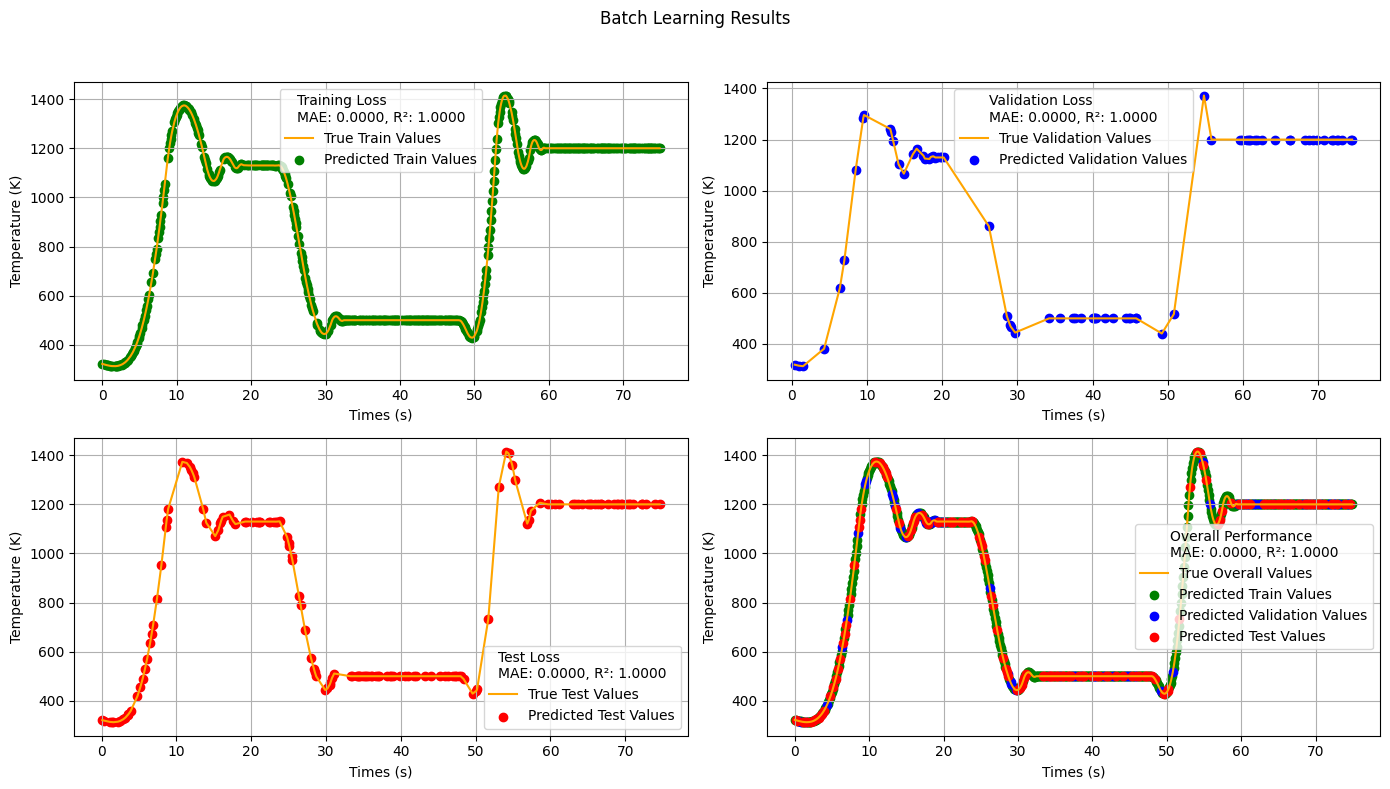

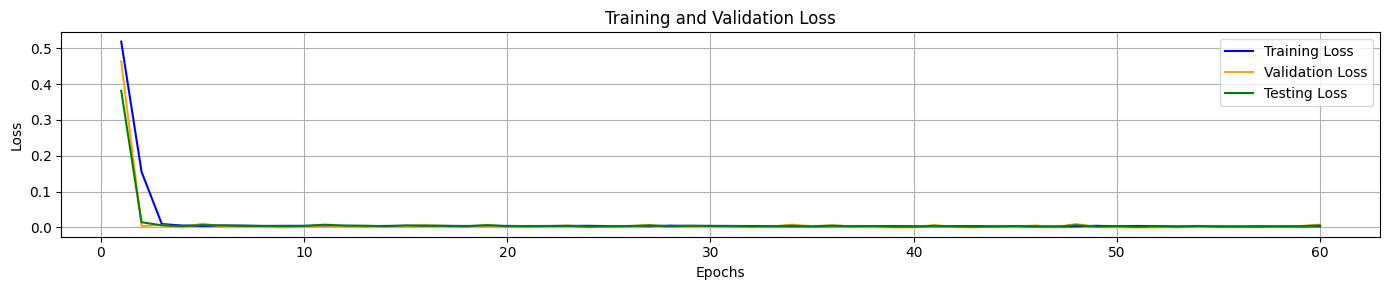

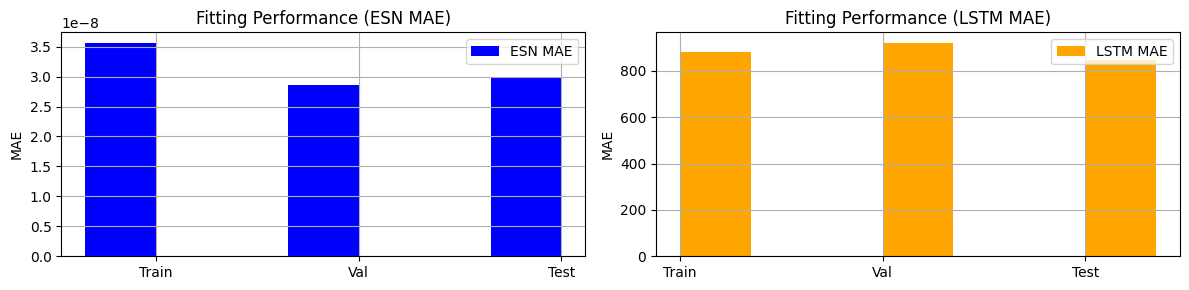

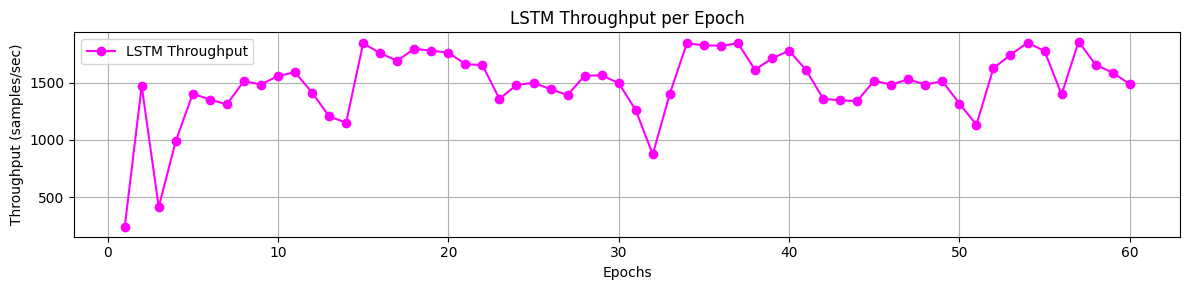

Processing Step: 1/750 | Setpoint: 1130
raw_input : [[  3.00000128   1.         321.30349018 322.        ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
Manual LSTM Prediction : 326.29144287109375
Feedback prev_temp : 326.29144287109375
Processing Step: 2/750 | Setpoint: 1130
raw_input : [[  4.00000129   3.00000128 320.40254595 326.29144287]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Manual LSTM Prediction : 326.1717834472656
Feedback prev_temp : 326.1717834472656
Processing Step: 3/750 | Setpoint: 1130
raw_input : [[  5.00000129   4.00000129 319.52525439 326.17178345]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Manual LSTM Prediction : 324.40509033203125
Feedback prev_temp : 324.40509033203125
Processing Step: 4/750 | Setpoint: 1130
raw_input : [[  6.00000129   5.00000129 318.67748261 324.40509033]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Manual LSTM P

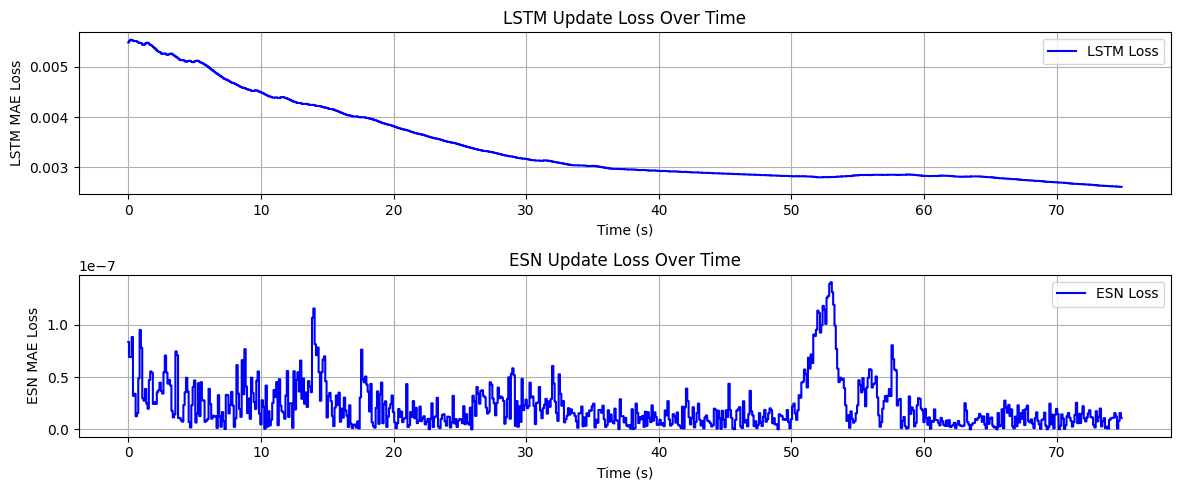

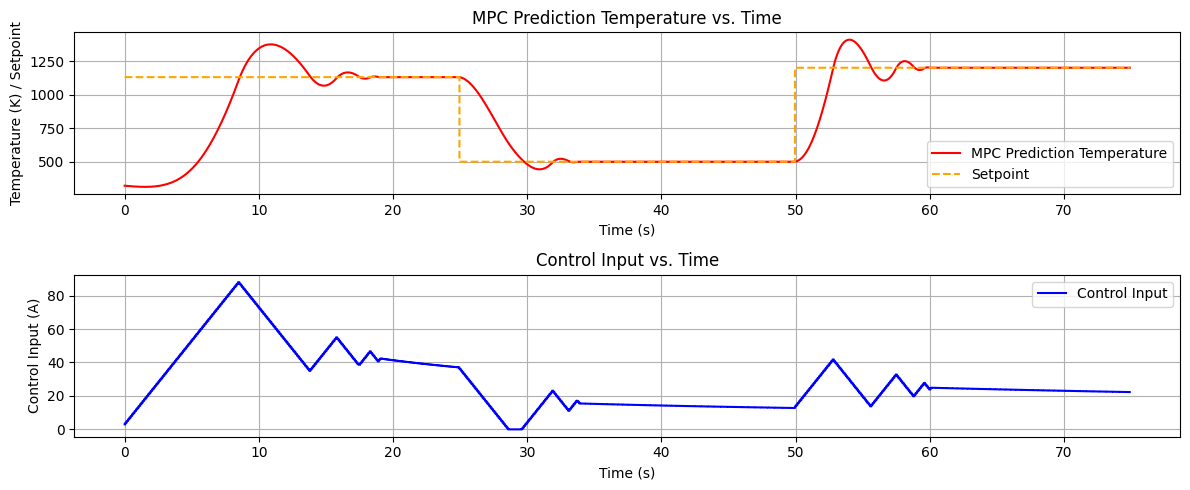

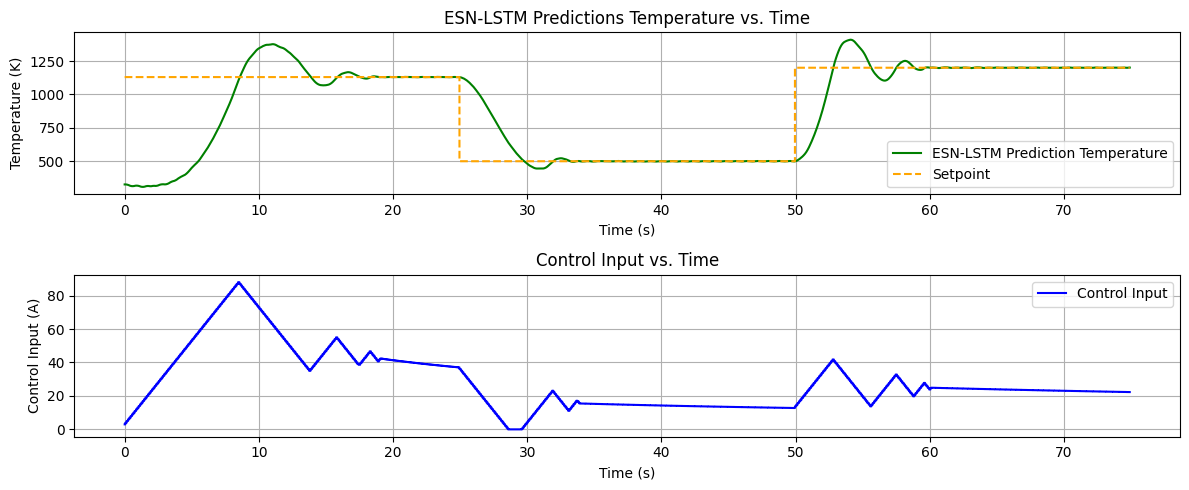

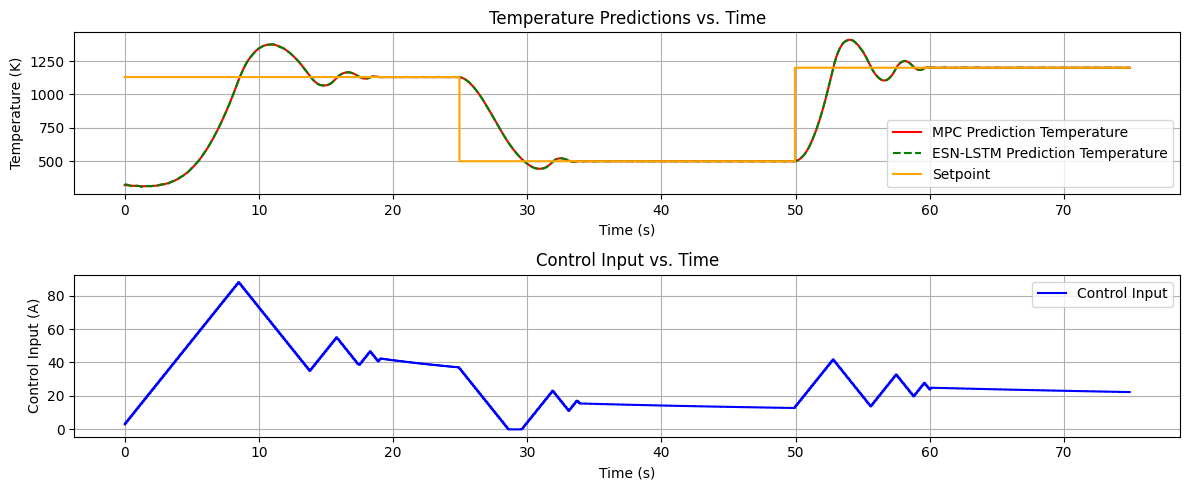

Data saved successfully in different sheets of the Excel file.
Full model state including internal states saved to D:\Python-Github-Projects\Model\4_input_MPC_ESN_LSTM_online_fullstate.pkl


In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import joblib
from sklearn.metrics import mean_absolute_error, r2_score
import time
import copy

# Import custom classes
from MPC_ModelReactor import ReactorMPC  # MPC simulation class
from ESN_online_01 import EchoStateNetwork  # ESN implementation (with get_state_online added)
from LSTM_online import LSTMonline       # LSTM online learning class

# =============================================================================
# Data Preprocessing Functions
# =============================================================================
def load_data(config):
    """Load data from an Excel file."""
    df = pd.read_excel(config['excel_file_path'], sheet_name=config['sheet_name'])
    X = df[config['input_columns']].values
    y = df[config['output_columns']].values
    return X, y

def save_scaler(scaler, filename):
    """ Save the scaler to a file. """
    joblib.dump(scaler, filename)

def scale_data(X, y, config):
    """Scale input and output data and save the scalers."""
    input_scaler = MinMaxScaler(feature_range=(-1, 1))
    output_scaler = MinMaxScaler(feature_range=(-1, 1))
    X_scaled = input_scaler.fit_transform(X)
    y_scaled = output_scaler.fit_transform(y)
    save_scaler(input_scaler, config['input_scaler_filename'])
    save_scaler(output_scaler, config['output_scaler_filename'])
    print(f"Input scaler saved to: {config['input_scaler_filename']}")
    print(f"Output scaler saved to: {config['output_scaler_filename']}")
    return X_scaled, y_scaled, input_scaler, output_scaler

def split_data(X_scaled, y_scaled, config):
    """Split scaled data into train, validation, and test sets."""
    train_ratio = config['train_ratio']
    val_ratio = config['val_ratio']
    test_ratio = config['test_ratio']

    n_samples = len(X_scaled)
    indices = np.arange(n_samples)
    np.random.seed(config.get('random_seed', 42))
    np.random.shuffle(indices)

    n_train = int(train_ratio * n_samples)
    n_val = int(val_ratio * n_samples)
    n_test = n_samples - n_train - n_val

    train_indices = np.sort(indices[:n_train])
    val_indices = np.sort(indices[n_train:n_train + n_val])
    test_indices = np.sort(indices[n_train + n_val:])

    assign = np.empty(n_samples, dtype=object)
    assign[train_indices] = 'train'
    assign[val_indices] = 'val'
    assign[test_indices] = 'test'

    X_train = X_scaled[train_indices]
    y_train = y_scaled[train_indices]
    X_val = X_scaled[val_indices]
    y_val = y_scaled[val_indices]
    X_test = X_scaled[test_indices]
    y_test = y_scaled[test_indices]

    return X_train, y_train, X_val, y_val, X_test, y_test, assign

# =============================================================================
# Model Training Functions (Batch Training)
# =============================================================================
def batch_training(X_train, y_train, X_test, y_test, config):
    # --- ESN Training ---
    start_esn = time.time()
    esn = EchoStateNetwork(
        input_dim=config['esn_input_dim'],
        output_dim=config['esn_output_dim'],
        reservoir_size=config['esn_reservoir_size'],
        spectral_radius=config['esn_spectral_radius'],
        connectivity=config['esn_connectivity'],
        noise=config['esn_noise'],
        washout=config['esn_washout'],
        ridge_alpha=config['esn_ridge_alpha'],
        lamda=config['esn_lamda'],
        random_state=config['esn_random_state'],
        include_bias=config['esn_include_bias'],
        output_feedback=config['esn_output_feedback']
    )
    esn.fit(X_train, y_train, washout=config['esn_washout'], ridge_alpha=config['esn_ridge_alpha'])
    end_esn = time.time()
    esn_time = end_esn - start_esn
    throughput_esn = len(X_train) / esn_time
    print("ESN Training Time: {:.2f} sec, Throughput: {:.2f} samples/sec".format(esn_time, throughput_esn))

    # Compute ESN features for training and test sets
    esn_features_train = np.array([esn.predict(sample.reshape(1, -1))[0, 0] for sample in X_train]).reshape(-1, 1)
    esn_features_test = np.array([esn.predict(sample.reshape(1, -1))[0, 0] for sample in X_test]).reshape(-1, 1)

    # --- LSTM Batch Training ---
    lstm_input_train = esn_features_train.reshape(-1, 1, 1)
    lstm_input_test = esn_features_test.reshape(-1, 1, 1)

    lstm_model = LSTMonline(
        input_shape=config['lstm_input_shape'],
        lstm_units=config['lstm_units'],
        dense_units=config['lstm_dense_units'],
        learning_rate=config['lstm_learning_rate']
    )
    start_lstm = time.time()
    lstm_history = lstm_model.initial_train(lstm_input_train, y_train, 
                                              epochs=config['lstm_epochs'], 
                                              batch_size=config['lstm_batch_size'],
                                              test_data=(lstm_input_test, y_test))
    end_lstm = time.time()
    lstm_time = end_lstm - start_lstm
    throughput_lstm = len(X_train) / lstm_time
    print("LSTM Training Time: {:.2f} sec, Throughput: {:.2f} samples/sec".format(lstm_time, throughput_lstm))

    lstm_model.history = lstm_history
    return esn, lstm_model, throughput_esn, throughput_lstm

# =============================================================================
# Online Learning Simulation Function with Dynamic Setpoint
# =============================================================================
def online_learning_simulation(esn, lstm_model, scaler_X, scaler_y, reactor_mpc, config):
    max_online_steps = config['max_online_steps']
    delta_t = config['delta_t']


    # Initialize lists to record histories.
    raw_input_history = []
    lstm_hidden_history = []        # To record LSTM hidden state (if available)
    lstm_cell_history = []          # To record LSTM cell state (if available)
    esn_weights_history = []        # To record the full ESN weights each step
    esn_output_history = []
    lstm_weights_history = []       # To record the full LSTM weights each step
    lstm_output_history = []
    mpc_setpoint_history = []
    online_predictions = []
    online_losses_lstm = []
    online_losses_esn = []
    mpc_temp_history = []
    mpc_control_history = []
    
    # Initialize previous control and temperature from the reactor
    prev_control = reactor_mpc.control_sequence[-1]
    state = reactor_mpc.update()
    prev_temp = 322
        
    # Online update loop
    for step in range(max_online_steps):
        current_time = step + 1  # assuming delta_t is 1
        # Update setpoint from schedule
        for sched in config['setpoint_schedule']:
            if sched['start'] <= current_time <= sched['end']:
                reactor_mpc.setpoint = sched['setpoint']
                break
        mpc_setpoint_history.append(reactor_mpc.setpoint)
        
        print(f"Processing Step: {current_time}/{max_online_steps} | Setpoint: {reactor_mpc.setpoint}")
        state = reactor_mpc.update()
        current_control = state['I0_control (A)']
        current_temp = state['Temperature (K)']
        
        # Prepare input for ESN (scaling and reshaping)
        #raw_input = np.array([current_control, prev_control, prev_temp]).reshape(1, 3)
        raw_input = np.array([current_control, prev_control, current_temp, prev_temp]).reshape(1, 4)
        print(f"raw_input : {raw_input}")
        raw_input_history.append(raw_input.flatten())
        online_esn_input = scaler_X.transform(raw_input)
        scaled_online_input = online_esn_input[0]
        
        # ESN prediction
        esn_output_online = esn.predict(online_esn_input)[0, 0]
        esn_output_history.append(esn_output_online)

        # LSTM prediction update
        lstm_online_input = np.array([[esn_output_online]]).reshape(1, 1, 1)
        pred_temp_scaled = lstm_model.predict(lstm_online_input)[0, 0]
        lstm_output_history.append(pred_temp_scaled)
        h_state, c_state = lstm_model.state_model.predict(lstm_online_input)
        lstm_hidden_history.append(h_state)
        lstm_cell_history.append(c_state)
        pred_temp = scaler_y.inverse_transform(np.array([[pred_temp_scaled]]))[0, 0]
        online_predictions.append(pred_temp)
        
        # Feed back the predicted temperature
        prev_temp = pred_temp
        print(f"Manual LSTM Prediction : {pred_temp}")
        print(f"Feedback prev_temp : {prev_temp}")
        
        # Online update for LSTM and ESN
        target_scaled = scaler_y.transform(np.array([[current_temp]]))
        loss_lstm = lstm_model.online_update(lstm_online_input, target_scaled)
        online_losses_lstm.append(loss_lstm)
        
        scaled_target = scaler_y.transform(np.array([[current_temp]]))[0]
        loss_esn = esn.online_update(scaled_online_input, scaled_target)
        online_losses_esn.append(loss_esn)
        
        mpc_temp_history.append(current_temp)
        mpc_control_history.append(current_control)
        prev_control = current_control
        
        # Record weight snapshots
        esn_weights_history.append(copy.deepcopy(esn.get_weights()))
        lstm_weights_history.append(copy.deepcopy(lstm_model.model.get_weights()))

    # Retrieve online ESN states recorded during the updates
    esn_states_history = esn.get_state_online()
    
    # Return all collected histories.
    return (esn_output_history, lstm_output_history, online_predictions, 
            online_losses_lstm, online_losses_esn, mpc_temp_history, 
            mpc_control_history, mpc_setpoint_history, esn_states_history, 
            lstm_hidden_history, lstm_cell_history, esn_weights_history, 
            lstm_weights_history, raw_input_history)

# =============================================================================
# Fitting Performance Functions
# =============================================================================
def compute_metrics(true_vals, pred_vals):
    mae = mean_absolute_error(true_vals, pred_vals)
    r2 = r2_score(true_vals, pred_vals)
    return mae, r2

def compute_fitting_performance(esn, lstm_model, X_train, y_train, X_val, y_val, X_test, y_test, scaler_y):
    """Compute performance (MAE, R²) for ESN and LSTM on Train, Val, and Test sets."""
    # ESN performance
    esn_train_preds = esn.predict(X_train)
    esn_val_preds = esn.predict(X_val)
    esn_test_preds = esn.predict(X_test)
    esn_train_mae, esn_train_r2 = compute_metrics(y_train, esn_train_preds)
    esn_val_mae, esn_val_r2 = compute_metrics(y_val, esn_val_preds)
    esn_test_mae, esn_test_r2 = compute_metrics(y_test, esn_test_preds)

    # LSTM performance
    def get_lstm_preds(X):
        feats = [esn.predict(sample.reshape(1, -1))[0, 0] for sample in X]
        feats = np.array(feats).reshape(-1, 1)
        lstm_input = feats.reshape(-1, 1, 1)
        preds_scaled = lstm_model.predict(lstm_input)
        preds = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1))
        return preds

    lstm_train_preds = get_lstm_preds(X_train)
    lstm_val_preds = get_lstm_preds(X_val)
    lstm_test_preds = get_lstm_preds(X_test)
    lstm_train_mae, lstm_train_r2 = compute_metrics(y_train, lstm_train_preds)
    lstm_val_mae, lstm_val_r2 = compute_metrics(y_val, lstm_val_preds)
    lstm_test_mae, lstm_test_r2 = compute_metrics(y_test, lstm_test_preds)

    return {
        'ESN': {
            'train_mae': esn_train_mae, 'train_r2': esn_train_r2,
            'val_mae': esn_val_mae, 'val_r2': esn_val_r2,
            'test_mae': esn_test_mae, 'test_r2': esn_test_r2,
        },
        'LSTM': {
            'train_mae': lstm_train_mae, 'train_r2': lstm_train_r2,
            'val_mae': lstm_val_mae, 'val_r2': lstm_val_r2,
            'test_mae': lstm_test_mae, 'test_r2': lstm_test_r2,
        }
    }

# =============================================================================
# Plotting Functions (Including Throughput Plot)
# =============================================================================
def batch_plot_result(scaler_y, y_train, train_preds, y_val, val_preds, y_test, test_preds,
                      y_scaled, lstm_history, fitting_metrics, assign, num_train_samples, delta_t,
                      train_mae, train_r2, val_mae, val_r2, test_mae, test_r2, overall_mae, overall_r2,
                      result_dir, config):
    # Compute time array for online simulation
    total_samples = len(y_scaled) 
    time_arr = np.arange(total_samples) * config['delta_t']

    # Reassemble predictions into original order
    overall_pred_scaled = np.empty_like(y_scaled)
    train_count = val_count = test_count = 0
    for i in range(len(y_scaled)):
        if assign[i] == 'train':
            overall_pred_scaled[i] = train_preds[train_count]
            train_count += 1
        elif assign[i] == 'val':
            overall_pred_scaled[i] = val_preds[val_count]
            val_count += 1
        else:
            overall_pred_scaled[i] = test_preds[test_count]
            test_count += 1
    overall_pred = scaler_y.inverse_transform(overall_pred_scaled)
    y_true_all = scaler_y.inverse_transform(y_scaled)
    
    # Indices for train, val, and test
    train_idx = np.where(assign == 'train')[0]
    val_idx = np.where(assign == 'val')[0]
    test_idx = np.where(assign == 'test')[0]

    # --- Batch Performance Plots ---
    plt.figure(figsize=(14, 8))
    train_true_ordered = y_true_all[train_idx]
    train_pred_ordered = overall_pred[train_idx]
    plt.subplot(2, 2, 1)
    plt.plot(time_arr[train_idx], train_true_ordered, color='orange', linestyle='-', label='True Train Values')
    plt.scatter(time_arr[train_idx], train_pred_ordered, color='green', marker='o', label='Predicted Train Values')
    plt.legend(title=f'Training Loss\nMAE: {train_mae:.4f}, R²: {train_r2:.4f}')
    plt.xlabel('Times (s)')
    plt.ylabel('Temperature (K)')
    plt.grid(True)
    plt.subplot(2, 2, 2)
    val_true_ordered = y_true_all[val_idx]
    val_pred_ordered = overall_pred[val_idx]
    plt.plot(time_arr[val_idx], val_true_ordered, color='orange', linestyle='-', label='True Validation Values')
    plt.scatter(time_arr[val_idx], val_pred_ordered, color='blue', marker='o', label='Predicted Validation Values')
    plt.legend(title=f'Validation Loss\nMAE: {val_mae:.4f}, R²: {val_r2:.4f}')
    plt.xlabel('Times (s)')
    plt.ylabel('Temperature (K)')
    plt.grid(True)
    plt.subplot(2, 2, 3)
    test_true_ordered = y_true_all[test_idx]
    test_pred_ordered = overall_pred[test_idx]
    plt.plot(time_arr[test_idx], test_true_ordered, color='orange', linestyle='-', label='True Test Values')
    plt.scatter(time_arr[test_idx], test_pred_ordered, color='red', marker='o', label='Predicted Test Values')
    plt.legend(title=f'Test Loss\nMAE: {test_mae:.4f}, R²: {test_r2:.4f}')
    plt.xlabel('Times (s)')
    plt.ylabel('Temperature (K)')
    plt.grid(True)
    plt.subplot(2, 2, 4)
    plt.plot(time_arr, y_true_all, color='orange', linestyle='-', label='True Overall Values')
    plt.scatter(time_arr[train_idx], train_pred_ordered, color='green', marker='o', label='Predicted Train Values')
    plt.scatter(time_arr[val_idx], val_pred_ordered, color='blue', marker='o', label='Predicted Validation Values')
    plt.scatter(time_arr[test_idx], test_pred_ordered, color='red', marker='o', label='Predicted Test Values')
    plt.legend(title=f'Overall Performance\nMAE: {overall_mae:.4f}, R²: {overall_r2:.4f}')
    plt.xlabel('Times (s)')
    plt.ylabel('Temperature (K)')
    plt.suptitle("Batch Learning Results")
    plt.grid(True)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(os.path.join(result_dir, f"{config['code_name']}_MPC_batch_performance.png"))
    plt.show()

    # --- Fitting Performance Plots ---
    epochs = np.arange(1, len(lstm_history['loss']) + 1)
    plt.figure(figsize=(14, 3))
    plt.plot(epochs, lstm_history['loss'], color='blue', linestyle='-', label='Training Loss')
    plt.plot(epochs, lstm_history['val_loss'], color='orange', linestyle='-', label='Validation Loss')
    plt.plot(epochs, lstm_history['test_loss'], color='green', linestyle='-', label='Testing Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, f"{config['code_name']}_MPC_fitting_performance.png"))
    plt.show()

    labels = ['Train', 'Val', 'Test']
    x = np.arange(len(labels))
    esn_mae_vals = [fitting_metrics['ESN']['train_mae'], fitting_metrics['ESN']['val_mae'],
                    fitting_metrics['ESN']['test_mae']]
    lstm_mae_vals = [fitting_metrics['LSTM']['train_mae'], fitting_metrics['LSTM']['val_mae'],
                     fitting_metrics['LSTM']['test_mae']]

    plt.figure(figsize=(12, 3))
    plt.subplot(1, 2, 1)
    plt.bar(x - 0.175, esn_mae_vals, 0.35, color='blue', label='ESN MAE')
    plt.xticks(x, labels)
    plt.ylabel('MAE')
    plt.title('Fitting Performance (ESN MAE)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    
    plt.subplot(1, 2, 2)
    plt.bar(x + 0.175, lstm_mae_vals, 0.35, color='orange', label='LSTM MAE')
    plt.xticks(x, labels)
    plt.ylabel('MAE')
    plt.title('Fitting Performance (LSTM MAE)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, f"{config['code_name']}_MPC_fitting_performance_bar.png"))
    plt.show()

    # --- Throughput Performance Plot per Epoch for LSTM ---
    epoch_times = lstm_history.get('epoch_times', None)
    if epoch_times is not None:
        throughput_per_epoch = [num_train_samples / t if t > 0 else 0 for t in epoch_times]
        epoch_range = np.arange(1, len(epoch_times) + 1)
        plt.figure(figsize=(12, 3))
        plt.plot(epoch_range, throughput_per_epoch, marker='o', linestyle='-', color='magenta', label='LSTM Throughput')
        plt.xlabel('Epochs')
        plt.ylabel('Throughput (samples/sec)')
        plt.title('LSTM Throughput per Epoch')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(result_dir, f"{config['code_name']}_MPC_throughput_per_epoch.png"))
        plt.show()
    else:
        print("Epoch timing information not available in LSTM history.")

def online_plot_result(mpc_temp_history, mpc_control_history, mpc_setpoint_history, online_predictions, 
                       online_losses_lstm, online_losses_esn, delta_t, result_dir, config):
    # --- Online Performance Plots ---
    plt.figure(figsize=(12, 5))
    plt.subplot(2, 1, 1)
    plt.step(np.arange(len(mpc_temp_history)) * config['delta_t'], online_losses_lstm, label='LSTM Loss', where='mid', color='blue')
    plt.xlabel('Time (s)')
    plt.ylabel('LSTM MAE Loss')
    plt.title('LSTM Update Loss Over Time')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.subplot(2, 1, 2)
    plt.step(np.arange(len(mpc_temp_history)) * config['delta_t'], online_losses_esn, label='ESN Loss', where='mid', color='blue')
    plt.xlabel('Time (s)')
    plt.ylabel('ESN MAE Loss')
    plt.title('ESN Update Loss Over Time')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, f"{config['code_name']}_MPC_online_performance.png"))
    plt.show()
    
    # --- Time-Based Plots: Temperature and Setpoint ---
    plt.figure(figsize=(12, 5))
    plt.subplot(2, 1, 1)
    plt.plot(np.arange(len(mpc_temp_history)) * config['delta_t'], mpc_temp_history, color='red', linestyle='-', label='MPC Prediction Temperature')
    plt.step(np.arange(len(mpc_temp_history)) * config['delta_t'], mpc_setpoint_history, color='orange', linestyle='--', where='mid', label='Setpoint')
    plt.xlabel('Time (s)')
    plt.ylabel('Temperature (K) / Setpoint')
    plt.title('MPC Prediction Temperature vs. Time')
    plt.legend()   
    plt.grid(True)
    plt.subplot(2, 1, 2)
    plt.step(np.arange(len(mpc_temp_history)) * config['delta_t'], mpc_control_history, color='blue', label='Control Input', where='mid')
    plt.xlabel('Time (s)')
    plt.ylabel('Control Input (A)')
    plt.title('Control Input vs. Time')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, f"{config['code_name']}_MPC_temperature_setpoint.png"))
    plt.show()
    
    # --- Additional Plot: ESN-LSTM Prediction ---
    plt.figure(figsize=(12, 5))
    plt.subplot(2, 1, 1)
    plt.plot(np.arange(len(mpc_temp_history)) * config['delta_t'], online_predictions, color='green', linestyle='-', label='ESN-LSTM Prediction Temperature')
    plt.step(np.arange(len(mpc_temp_history)) * config['delta_t'], mpc_setpoint_history, color='orange', linestyle='--', where='mid', label='Setpoint')
    plt.xlabel('Time (s)')
    plt.ylabel('Temperature (K)')
    plt.title('ESN-LSTM Predictions Temperature vs. Time')
    plt.legend()
    plt.grid(True)
    plt.subplot(2, 1, 2)
    plt.step(np.arange(len(mpc_temp_history)) * config['delta_t'], mpc_control_history, color='blue', label='Control Input', where='mid')
    plt.xlabel('Time (s)')
    plt.ylabel('Control Input (A)')
    plt.title('Control Input vs. Time')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, f"{config['code_name']}_MPC_esn_lstm_prediction.png"))
    plt.show()
    
    # --- Combination Plot: MPC and ESN-LSTM ---
    plt.figure(figsize=(12, 5))
    plt.subplot(2, 1, 1)
    plt.plot(np.arange(len(mpc_temp_history)) * config['delta_t'], mpc_temp_history, color='red', linestyle='-', label='MPC Prediction Temperature')
    plt.plot(np.arange(len(mpc_temp_history)) * config['delta_t'], online_predictions, color='green', linestyle='--', label='ESN-LSTM Prediction Temperature')
    plt.step(np.arange(len(mpc_temp_history)) * config['delta_t'], mpc_setpoint_history, color='orange', linestyle='-', where='mid', label='Setpoint')
    plt.xlabel('Time (s)')
    plt.ylabel('Temperature (K)')
    plt.title('Temperature Predictions vs. Time')
    plt.legend()
    plt.grid(True)
    plt.subplot(2, 1, 2)
    plt.step(np.arange(len(mpc_temp_history)) * config['delta_t'], mpc_control_history, color='blue', linestyle='-', label='Control Input', where='mid')
    plt.xlabel('Time (s)')
    plt.ylabel('Control Input (A)')
    plt.title('Control Input vs. Time')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, f"{config['code_name']}_MPC_combination_plot.png"))
    plt.show()

def store_printed_values_to_excel(train_idx, train_true_ordered, train_pred_ordered,
                                  val_idx, val_true_ordered, val_pred_ordered,
                                  test_idx, test_true_ordered, test_pred_ordered,
                                  epochs, lstm_history, esn_mae_vals, lstm_mae_vals,
                                  epoch_range, throughput_per_epoch,
                                  online_losses_lstm, online_losses_esn,
                                  time_arr, mpc_control_history, mpc_temp_history,
                                  mpc_setpoint_history, online_predictions, train_mae, 
                                  train_r2, val_mae, val_r2, test_mae, test_r2,
                                  overall_mae, overall_r2, config):
    # Flatten arrays so each value goes to its own Excel cell
    train_true_ordered_flat = train_true_ordered.flatten()
    train_pred_ordered_flat = train_pred_ordered.flatten()
    
    val_true_ordered_flat = val_true_ordered.flatten()
    val_pred_ordered_flat = val_pred_ordered.flatten()
    
    test_true_ordered_flat = test_true_ordered.flatten()
    test_pred_ordered_flat = test_pred_ordered.flatten()
    
    # Prepare DataFrames
    train = {
        "Train X (indices)": train_idx,
        "Train Y (true values)": train_true_ordered_flat,
        "Train Y (predicted values)": train_pred_ordered_flat
    }
    val = {
        "Validation X (indices)": val_idx,
        "Validation Y (true values)": val_true_ordered_flat,
        "Validation Y (predicted values)": val_pred_ordered_flat
    }
    test = {
        "Test X (indices)": test_idx,
        "Test Y (true values)": test_true_ordered_flat,
        "Test Y (predicted values)": test_pred_ordered_flat
    }
    matrices = {
        'Metric': [
            'Train MAE', 'Train R²',
            'Validation MAE', 'Validation R²',
            'Test MAE', 'Test R²',
            'Overall MAE', 'Overall R²'
        ],
        'Value': [
            train_mae, train_r2,
            val_mae, val_r2,
            test_mae, test_r2,
            overall_mae, overall_r2
        ]
    }
    batch_loss = {
        "Epochs": list(range(1, epochs + 1)),
        "Training Loss": lstm_history['loss'],
        "Validation Loss": lstm_history['val_loss'],
        "Testing Loss": lstm_history['test_loss']
    }
    err = {
        "ESN MAE values": esn_mae_vals,
        "LSTM MAE values": lstm_mae_vals
    }
    throughput = {
        "Epoch range": epoch_range,
        "Throughput per epoch": throughput_per_epoch
    }
    online_loss = {
        "Time Array": time_arr,
        "Online LSTM Loss": online_losses_lstm,
        "Online ESN Loss": online_losses_esn
    }
    mpc_pred = {
        "Time Array": time_arr,
        "Control Input": mpc_control_history,
        "MPC Temperature History": mpc_temp_history,
        "MPC Setpoint History": mpc_setpoint_history
    }
    esn_lstm_pred = {
        "Time Array": time_arr,
        "Control Input": mpc_control_history,
        "ESN-LSTM Predictions": online_predictions,
        "MPC Setpoint History": mpc_setpoint_history
    }
    mpc_esn_lstm_pred = {
        "Time Array": time_arr,
        "Control Input": mpc_control_history,
        "MPC Temperature History": mpc_temp_history,
        "ESN-LSTM Predictions": online_predictions,
        "MPC Setpoint History": mpc_setpoint_history
    }
    
    # Write all DataFrames to an Excel file with multiple sheets
    with pd.ExcelWriter(os.path.join(config['result_dir'], config['file_name'])) as writer:
        pd.DataFrame(train).to_excel(writer, sheet_name='Train Data', index=False)
        pd.DataFrame(val).to_excel(writer, sheet_name='Validation Data', index=False)
        pd.DataFrame(test).to_excel(writer, sheet_name='Test Data', index=False)
        pd.DataFrame(matrices).to_excel(writer, sheet_name='Batch Matrices', index=False)
        pd.DataFrame(batch_loss).to_excel(writer, sheet_name='Batch Loss', index=False)
        pd.DataFrame(err).to_excel(writer, sheet_name='Error Metrics', index=False)
        pd.DataFrame(throughput).to_excel(writer, sheet_name='Throughput', index=False)
        pd.DataFrame(online_loss).to_excel(writer, sheet_name='Online Losses', index=False)
        pd.DataFrame(mpc_pred).to_excel(writer, sheet_name='MPC Predictions', index=False)
        pd.DataFrame(esn_lstm_pred).to_excel(writer, sheet_name='ESN-LSTM Predictions', index=False)
        pd.DataFrame(mpc_esn_lstm_pred).to_excel(writer, sheet_name='MPC ESN-LSTM Predictions', index=False)
    
    print("Data saved successfully in different sheets of the Excel file.")

# =============================================================================
# Main Function
# =============================================================================
def main():
    # ------------------------
    # Configuration
    # ------------------------
    config = {
        'code_name' : "4_input",
        'excel_file_path': r"D:\Python-Github-Projects\Model\MPC Control Result 17N.xlsx",
        'sheet_name': "Lagged_MPC_Reactor_17N_01",
        #'input_columns': ["k-0 I0_control (A)", "k-1 I0_control (A)", "k-1 Temperature (K)"],
        'input_columns': ["k-0 I0_control (A)", "k-1 I0_control (A)", "k-0 Temperature (K)", "k-1 Temperature (K)"],
        'output_columns': ["k-0 Temperature (K)"],
        'train_ratio': 0.7,
        'val_ratio': 0.1,
        'test_ratio': 0.2,
        'random_seed': 56,
        # ESN hyperparameters
        'esn_input_dim': 4,
        'esn_output_dim': 1,
        'esn_reservoir_size': 50, #200
        'esn_spectral_radius': 0.9,
        'esn_connectivity': 0.5, #0.4
        'esn_noise': 0,
        'esn_random_state': 56,
        'esn_washout': 0,
        'esn_ridge_alpha': 1e-6,
        'esn_lamda':1,
        'esn_include_bias': True,
        'esn_output_feedback': True,
        # LSTM hyperparameters
        'lstm_input_shape': (1, 1),
        'lstm_units': 50,
        'lstm_dense_units': 1,
        'lstm_learning_rate': 0.001,
        'lstm_epochs': 60,
        'lstm_batch_size': 4,
        # MPC parameters
        'mpc_initial_control_sequence': [1],
        'mpc_delta_u_max': 1,
        'mpc_u_min': 0.01,
        'mpc_u_max': 130,
        'mpc_R_weight': 0.001,
        'mpc_Q_weight': 0.01,
        'mpc_optimizer': 'slsqp',
        'mpc_prediction_horizon': 20,
        'mpc_control_horizon': 5,
        # Online simulation parameters
        'delta_t': 0.1,
        'max_online_steps': 750,
        'T_stps': [1130, 500, 1200],
        # Directory to save all figures and full model state
        'result_dir': r"D:\Python-Github-Projects\Model",
    }

    # ------------------------
    # Dynamic filename assignments
    # ------------------------
    config['input_scaler_filename'] = os.path.join(config['result_dir'], f"{config['code_name']}_MPC_scaler_X.pkl")
    config['output_scaler_filename'] = os.path.join(config['result_dir'], f"{config['code_name']}_MPC_scaler_y.pkl")
    config['esn_model_filename'] = os.path.join(config['result_dir'], f"{config['code_name']}_MPC_esn_model.pkl")
    config['lstm_model_filename'] = os.path.join(config['result_dir'], f"{config['code_name']}_MPC_lstm_model.keras")
    config['file_name'] = os.path.join(config['result_dir'], f"{config['code_name']}_MPC_online_result.xlsx")

    # Compute setpoint schedule dynamically
    T_stps = config['T_stps']
    n_sp = len(T_stps)
    chunk = config['max_online_steps'] // n_sp
    setpoint_schedule = []
    for i, sp in enumerate(T_stps):
        start = i * chunk + 1
        end = config['max_online_steps'] if i == n_sp - 1 else (i + 1) * chunk
        setpoint_schedule.append({'start': start, 'end': end, 'setpoint': sp})
    config['setpoint_schedule'] = setpoint_schedule
    print("Computed setpoint schedule:", setpoint_schedule)

    # ------------------------
    # Data Preprocessing
    # ------------------------
    X, y = load_data(config)
    X_scaled, y_scaled, scaler_X, scaler_y = scale_data(X, y, config)
    X_train, y_train, X_val, y_val, X_test, y_test, assign = split_data(X_scaled, y_scaled, config)

    # Extract indices for train, val, and test
    train_idx = np.where(assign == 'train')[0]
    val_idx = np.where(assign == 'val')[0]
    test_idx = np.where(assign == 'test')[0]

    # Define true values for train, validation, and test sets
    train_true_ordered = y_train
    val_true_ordered = y_val
    test_true_ordered = y_test

    # ------------------------
    # Batch Training for ESN and LSTM
    # ------------------------
    esn, lstm_model, throughput_esn, throughput_lstm = batch_training(X_train, y_train, X_test, y_test, config)
    print("Throughput Performance - ESN: {:.2f} samples/sec, LSTM: {:.2f} samples/sec".format(throughput_esn, throughput_lstm))

    # Batch predictions and metrics
    train_preds = esn.predict(X_train)
    val_preds = esn.predict(X_val)
    test_preds = esn.predict(X_test)

    # Store the true and predicted values for later use
    train_pred_ordered = train_preds
    val_pred_ordered = val_preds
    test_pred_ordered = test_preds

    train_mae, train_r2 = compute_metrics(y_train, train_preds)
    val_mae, val_r2 = compute_metrics(y_val, val_preds)
    test_mae, test_r2 = compute_metrics(y_test, test_preds)
    overall_true = np.concatenate([y_train, y_val, y_test])
    overall_pred = np.concatenate([train_preds, val_preds, test_preds])
    overall_mae, overall_r2 = compute_metrics(overall_true, overall_pred)
    
    print(f"Batch Learning - Train MAE: {train_mae}, Train R²: {train_r2}")
    print(f"Batch Learning - Validation MAE: {val_mae}, Validation R²: {val_r2}")
    print(f"Batch Learning - Test MAE: {test_mae}, Test R²: {test_r2}")
    print(f"Batch Learning - Overall MAE: {overall_mae}, Overall R²: {overall_r2}")

    fitting_metrics = compute_fitting_performance(esn, lstm_model, X_train, y_train, X_val, y_val, X_test, y_test, scaler_y)

    # ------------------------
    # Plot All Results (batch training)
    # ------------------------
    batch_plot_result(scaler_y, y_train, train_preds, y_val, val_preds, y_test, test_preds,
                      y_scaled, lstm_model.history, fitting_metrics, assign, len(X_train), config['delta_t'],
                      train_mae, train_r2, val_mae, val_r2, test_mae, test_r2, overall_mae, overall_r2, 
                      config['result_dir'], config)

    # ------------------------
    # Online Learning Simulation
    # ------------------------
    reactor_mpc = ReactorMPC(
        initial_control_sequence=config['mpc_initial_control_sequence'],
        setpoint=config['setpoint_schedule'][0]['setpoint'],
        delta_u_max=config['mpc_delta_u_max'],
        u_min=config['mpc_u_min'],
        u_max=config['mpc_u_max'],
        R_weight=config['mpc_R_weight'],
        Q_weight=config['mpc_Q_weight'],
        delta_t=config['delta_t'],
        optimizer=config['mpc_optimizer'],
        M=config['mpc_prediction_horizon'],
        N=config['mpc_control_horizon']
    )
    (esn_output_history, lstm_output_history, online_predictions, 
            online_losses_lstm, online_losses_esn, mpc_temp_history, 
            mpc_control_history, mpc_setpoint_history, esn_states_history, 
            lstm_hidden_history, lstm_cell_history, esn_weights_history, 
            lstm_weights_history, raw_input_history) = online_learning_simulation(
        esn, lstm_model, scaler_X, scaler_y, reactor_mpc, config
    )

    online_mae, online_r2 = compute_metrics(np.array(mpc_temp_history), np.array(online_predictions))
    print(f"Online Learning - MAE: {online_mae}, R²: {online_r2}")

    # ------------------------
    # Plot All Results (online training)
    # ------------------------
    online_plot_result(mpc_temp_history, mpc_control_history, mpc_setpoint_history, online_predictions, 
                       online_losses_lstm, online_losses_esn, config['delta_t'], config['result_dir'], config)
    
    # ------------------------
    # Save Results and Full Model State
    # ------------------------
    num_train_samples = len(X_train)
    epochs = len(lstm_model.history['loss'])
    lstm_history = lstm_model.history
    esn_mae_vals = [fitting_metrics['ESN']['train_mae'], fitting_metrics['ESN']['val_mae'], fitting_metrics['ESN']['test_mae']]
    lstm_mae_vals = [fitting_metrics['LSTM']['train_mae'], fitting_metrics['LSTM']['val_mae'], fitting_metrics['LSTM']['test_mae']]
    epoch_range = np.arange(1, epochs + 1)
    throughput_per_epoch = [num_train_samples / t if t > 0 else 0 for t in lstm_history.get('epoch_times', [])]
    time_arr = np.arange(len(mpc_temp_history)) * config['delta_t']
    
    store_printed_values_to_excel(train_idx, train_true_ordered, train_pred_ordered,
                                  val_idx, val_true_ordered, val_pred_ordered,
                                  test_idx, test_true_ordered, test_pred_ordered,
                                  epochs, lstm_history, esn_mae_vals, lstm_mae_vals,
                                  epoch_range, throughput_per_epoch,
                                  online_losses_lstm, online_losses_esn,
                                  time_arr, mpc_control_history, mpc_temp_history,
                                  mpc_setpoint_history, online_predictions, train_mae, 
                                  train_r2, val_mae, val_r2, test_mae, test_r2,
                                  overall_mae, overall_r2, config)


    # Save the full online model state including internal states to a single file
    model_state_history = {
        "esn_model": esn,
        "lstm_model": lstm_model.model,
        "raw_input": raw_input_history,
        "scaler_X": scaler_X,
        "scaler_y": scaler_y,
        "esn_states": esn_states_history,
        "lstm_hidden_states": lstm_hidden_history,
        "lstm_cell_states": lstm_cell_history,
        "esn_weights_history": esn_weights_history,
        "lstm_weights_history": lstm_weights_history,
        "esn_output_history" : esn_output_history,
        "lstm_output_history" : lstm_output_history,
        "online_predictions": online_predictions,
        "online_losses_lstm": online_losses_lstm,
        "online_losses_esn": online_losses_esn,
        "mpc_temp_history": mpc_temp_history,
        "mpc_control_history": mpc_control_history,
        "mpc_setpoint_history": mpc_setpoint_history,
    }
    full_state_filename = os.path.join(config['result_dir'], f"{config['code_name']}_MPC_ESN_LSTM_online_fullstate.pkl")
    if os.path.exists(full_state_filename):
        os.remove(full_state_filename)
    joblib.dump(model_state_history, full_state_filename)
    print(f"Full model state including internal states saved to {full_state_filename}")

    # ------------------------
    # Save Models and Scalers Separately
    # ------------------------
    joblib.dump(esn, config['esn_model_filename'])
    lstm_model.model.save(config['lstm_model_filename'])
    # print("Hybrid ESN-LSTM model ./and scalers saved successfully (ESN and scalers as .pkl, LSTM as .keras).")

if __name__ == "__main__":
    main()


<>:8: SyntaxWarning: invalid escape sequence '\P'
<>:8: SyntaxWarning: invalid escape sequence '\P'
C:\Users\rasiq\AppData\Local\Temp\ipykernel_16668\1576233114.py:8: SyntaxWarning: invalid escape sequence '\P'
  "D:\Python-Github-Projects\Model",



========== Step 0 ==========

ESN Input u: size (1, 4)
[[  3.00000128   1.         321.30349018 322.        ]]

Manual LSTM Prediction : size ()
312.00938918781605

========== Step 1 ==========

ESN Input u: size (1, 4)
[[  4.00000129   3.00000128 320.40254595 326.29144287]]

Manual LSTM Prediction : size ()
310.46867122759784

========== Step 2 ==========

ESN Input u: size (1, 4)
[[  5.00000129   4.00000129 319.52525439 326.17178345]]

Manual LSTM Prediction : size ()
307.83633266915416

========== Step 3 ==========

ESN Input u: size (1, 4)
[[  6.00000129   5.00000129 318.67748261 324.40509033]]

Manual LSTM Prediction : size ()
304.2240236867299

========== Step 4 ==========

ESN Input u: size (1, 4)
[[  7.00000129   6.00000129 317.86471716 321.15737915]]

Manual LSTM Prediction : size ()
302.10897415654694

========== Step 5 ==========

ESN Input u: size (1, 4)
[[  8.00000129   7.00000129 317.09220826 316.5710144 ]]

Manual LSTM Prediction : size ()
301.3546676614845

========== 

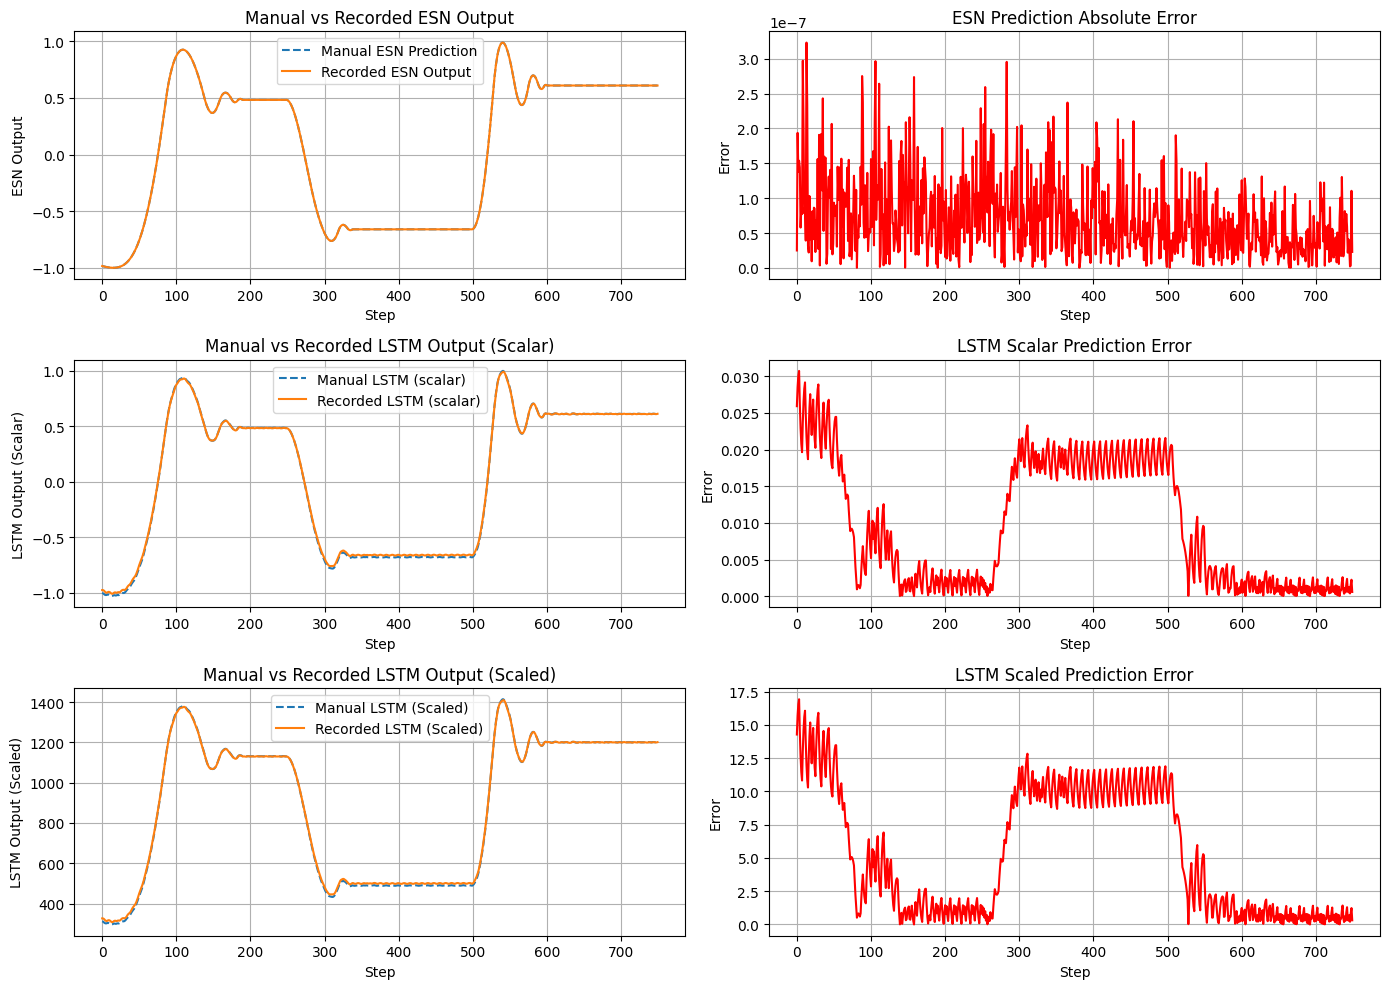

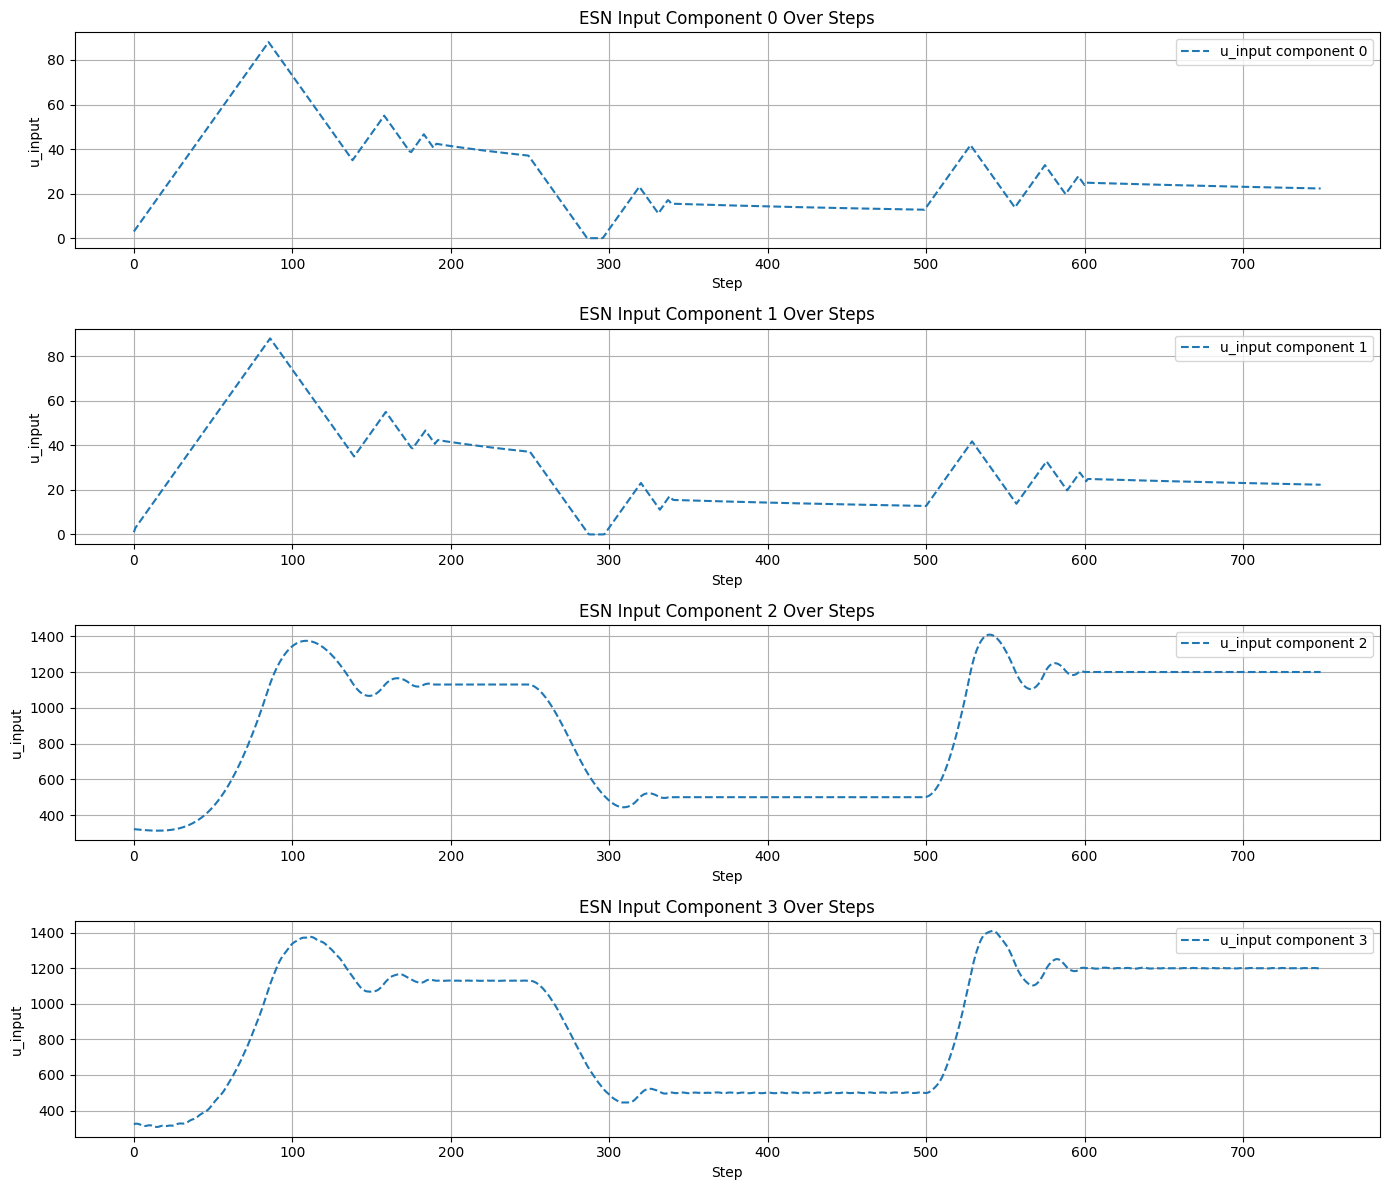

In [13]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt

# Load full model state
full_state_path = os.path.join(
    "D:\Python-Github-Projects\Model",
    "4_input_MPC_ESN_LSTM_online_fullstate.pkl"
)
model_state = joblib.load(full_state_path)

# Extract components
esn_weights_history = model_state["esn_weights_history"]
esn_states = model_state["esn_states"]
esn_output_history = model_state["esn_output_history"]
raw_input = model_state["raw_input"]
scaler_X = model_state["scaler_X"]
lstm_weights_history = model_state["lstm_weights_history"]
lstm_hidden_states = model_state["lstm_hidden_states"]
lstm_cell_states = model_state["lstm_cell_states"]
lstm_output_history = model_state["lstm_output_history"]
esn_output_history = model_state["esn_output_history"]
scaler_y = model_state.get("scaler_y")
lstm_dense = model_state["lstm_model"].layers[-1]
W_d = lstm_dense.get_weights()[0]
b_d = lstm_dense.get_weights()[1]

# ---------------------------------------------
# Activation functions
# ---------------------------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)
    
# Containers
u_esn_input = []

manual_preds_esn = []
recorded_preds_esn = []
diffs_esn = []

manual_preds_lstm_scalar = []
recorded_preds_lstm_scalar = []
diffs_lstm_scalar = []

manual_preds_lstm_scaled = []
recorded_preds_lstm_scaled = []
diffs_lstm_scaled = []

steps = np.arange(0, 750)

# Loop over steps 1 to 99
for step_index in steps:
    print(f"\n========== Step {step_index} ==========")

    # ESN forward
    params = esn_weights_history[step_index]
    W_in, W_res, W_out, W_fb, bias = params["W_in"], params["W_res"], params["W_out"], params["W_fb"], params["bias"]

    # Get and scale input
    u_input = raw_input[step_index].reshape(1, -1)
    u_scaled = scaler_X.transform(u_input).flatten()
    u_esn_input.append(u_input)

    # Previous state/output
    x_esn_prev = np.array(esn_states[step_index - 1][:50]).flatten()
    y_esn_prev = np.array(esn_output_history[step_index - 1]).flatten()

    # Manual forward pass
    pre_act = np.dot(W_in, u_scaled) + np.dot(W_res, x_esn_prev) + np.dot(W_fb, y_esn_prev) + bias
    x_extended = np.concatenate((pre_act, u_scaled, [bias]))
    y_esn_pred = np.dot(W_out, x_extended)[0]
    y_esn_recorded = esn_output_history[step_index]
    diff_esn = abs(y_esn_pred - y_esn_recorded)

    manual_preds_esn.append(y_esn_pred)
    recorded_preds_esn.append(y_esn_recorded)
    diffs_esn.append(diff_esn)

    # LSTM forward
    snapshot = lstm_weights_history[step_index]
    kernel, recurrent_kernel, bias = snapshot[0], snapshot[1], snapshot[2]
    H = bias.shape[0] // 4

    W_i, W_f, W_c, W_o = kernel[:, :H], kernel[:, H:2*H], kernel[:, 2*H:3*H], kernel[:, 3*H:]
    U_i, U_f, U_c, U_o = recurrent_kernel[:, :H], recurrent_kernel[:, H:2*H], recurrent_kernel[:, 2*H:3*H], recurrent_kernel[:, 3*H:]
    b_i, b_f, b_c, b_o = bias[:H], bias[H:2*H], bias[2*H:3*H], bias[3*H:]

    x_t = np.array([[y_esn_pred]])
    h_prev = np.zeros((1, H))
    c_prev = np.zeros((1, H))

    i_t = sigmoid(np.dot(x_t, W_i) + np.dot(h_prev, U_i) + b_i)
    f_t = sigmoid(np.dot(x_t, W_f) + np.dot(h_prev, U_f) + b_f)
    o_t = sigmoid(np.dot(x_t, W_o) + np.dot(h_prev, U_o) + b_o)
    c_hat_t = tanh(np.dot(x_t, W_c) + np.dot(h_prev, U_c) + b_c)

    c_t = f_t * c_prev + i_t * c_hat_t
    h_t = o_t * tanh(c_t)

    y_t = np.dot(h_t, W_d) + b_d
    y_t_scalar = y_t.flatten()[0]
    y_t_scaled = scaler_y.inverse_transform(np.array([[y_t_scalar]]))[0][0]

    y_recorded_scalar = lstm_output_history[step_index].flatten()[0]
    y_recorded_scaled = scaler_y.inverse_transform(np.array([[y_recorded_scalar]]))[0][0]

    manual_preds_lstm_scalar.append(y_t_scalar)
    recorded_preds_lstm_scalar.append(y_recorded_scalar)
    diffs_lstm_scalar.append(abs(y_t_scalar - y_recorded_scalar))

    manual_preds_lstm_scaled.append(y_t_scaled)
    recorded_preds_lstm_scaled.append(y_recorded_scaled)
    diffs_lstm_scaled.append(abs(y_t_scaled - y_recorded_scaled))

    #print(f"\nInput u: size {u_input.shape}")
    #print(u_input)
    #print(f"\nInput u_scaled: size {u_scaled.shape}")
    #print(u_scaled)
    #print(f"\nPrevious state x_prev: size {x_esn_prev.shape}")
    #print(x_esn_prev)
    #print(f"\nPrevious output y_prev: size {y_esn_prev.shape}")
    #print(y_esn_prev)
    #print(f"\nW_in : {W_in.shape}")
    #print(W_in)
    #print(f"\nW_res : {W_res.shape}")
    #print(W_res)
    #print(f"\nW_out : {W_out.shape}")
    #print(W_out)
    #print(f"\nW_fb : {W_fb.shape}")
    #print(W_fb)
    #print(f"\nbias : {bias}")
    #print(bias)
    #print(f"\nNew reservoir state x_new_extended: size {x_extended.shape}")
    #print(x_extended)
    #print(f"\nManual Predicted output y_pred ESN: {y_esn_pred}")
    #print(f"\nRecorded Predicted output y_pred ESN: {y_esn_recorded}")
    #print(f"\nAbsolute Difference: {diff_esn:.6e}")

    #print(f"\ninput x_t : size {x_t.shape}")
    #print(x_t)
    #print(f"\nW input (x_t) : size {W_i.shape}")
    #print(W_i)
    #print(f"\nW forget (x_t) : size {W_f.shape}")
    #print(W_f)
    #print(f"\nW candidate cell state (x_t) : size {W_c.shape}")
    #print(W_c)
    #print(f"\nW output (x_t) : size {W_o.shape}")
    #print(W_o)
    #print(f"\nU input (x_t) : size {U_i.shape}")
    #print(U_i)
    #print(f"\nU forget (x_t) : size {U_f.shape}")
    #print(U_f)
    #print(f"\nU candidate cell state (x_t) : size {U_c.shape}")
    #print(U_c)
    #print(f"\nU output (x_t) : size {U_o.shape}")
    #print(U_o)
    #print(f"\nb input (x_t) : size {b_i.shape}")
    #print(b_i)
    #print(f"\nb forget (x_t) : size {b_f.shape}")
    #print(b_f)
    #print(f"\nb candidate cell state (x_t) : size {b_c.shape}")
    #print(b_c)
    #print(f"\nb output (x_t) : size {b_o.shape}")
    #print(b_o)
    #print(f"\nHidden state prev : size {h_prev.shape}")
    #print(h_prev)
    #print(f"\nCell state prev : size {c_prev.shape}")
    #print(c_prev)
    #print(f"\nGate input (x_t) : size {i_t.shape}")
    #print(i_t)
    #print(f"\nGate forget (x_t) : size {f_t.shape}")
    #print(f_t)
    #print(f"\nGate candidate cell state (x_t) : size {c_hat_t.shape}")
    #print(c_hat_t)
    #print(f"\nGate output (x_t) : size {o_t.shape}")
    #print(o_t)
    #print(f"\nHidden state : size {h_t.shape}")
    #print(h_t)
    #print(f"\nCell state : size {c_t.shape}")
    #print(c_t)    
    #print(f"\nW dense : size {W_d.shape}")
    #print(W_d)
    #print(f"\nbias dense : size {b_d.shape}")
    #print(b_d)    
    #print(f"\nManual LSTM Prediction : size {y_t_scalar.shape}")
    #print(y_t_scalar)
    #print(f"\nRecorded LSTM Prediction : size {y_recorded_scalar.shape}")
    #print(y_recorded_scalar)
    #print(f"\nManual prediction: {y_t_scalar:.6f} | Recorded: {y_recorded_scalar:.6f} | Diff: {abs(y_t_scalar - y_recorded_scalar):.2e}")
    print(f"\nESN Input u: size {u_input.shape}")
    print(u_input)
    print(f"\nManual LSTM Prediction : size {y_t_scaled.shape}")
    print(y_t_scaled)


# Prepare plots
plt.figure(figsize=(14, 10))

# ESN output comparison
plt.subplot(3, 2, 1)
plt.plot(steps, manual_preds_esn, label="Manual ESN Prediction", linestyle='--')
plt.plot(steps, recorded_preds_esn, label="Recorded ESN Output", linestyle='-')
plt.title("Manual vs Recorded ESN Output")
plt.xlabel("Step")
plt.ylabel("ESN Output")
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 2)
plt.plot(steps, diffs_esn, color='red')
plt.title("ESN Prediction Absolute Error")
plt.xlabel("Step")
plt.ylabel("Error")
plt.grid(True)

# LSTM scalar output comparison
plt.subplot(3, 2, 3)
plt.plot(steps, manual_preds_lstm_scalar, label="Manual LSTM (scalar)", linestyle='--')
plt.plot(steps, recorded_preds_lstm_scalar, label="Recorded LSTM (scalar)", linestyle='-')
plt.title("Manual vs Recorded LSTM Output (Scalar)")
plt.xlabel("Step")
plt.ylabel("LSTM Output (Scalar)")
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 4)
plt.plot(steps, diffs_lstm_scalar, color='red')
plt.title("LSTM Scalar Prediction Error")
plt.xlabel("Step")
plt.ylabel("Error")
plt.grid(True)

# LSTM scaled output comparison
plt.subplot(3, 2, 5)
plt.plot(steps, manual_preds_lstm_scaled, label="Manual LSTM (Scaled)", linestyle='--')
plt.plot(steps, recorded_preds_lstm_scaled, label="Recorded LSTM (Scaled)", linestyle='-')
plt.title("Manual vs Recorded LSTM Output (Scaled)")
plt.xlabel("Step")
plt.ylabel("LSTM Output (Scaled)")
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 6)
plt.plot(steps, diffs_lstm_scaled, color='red')
plt.title("LSTM Scaled Prediction Error")
plt.xlabel("Step")
plt.ylabel("Error")
plt.grid(True)

plt.tight_layout()
plt.show()


# Convert list to a 2D array of shape (99, 3)
u_esn_input_arr = np.vstack(u_esn_input)
# Create subplots for each component
fig, axes = plt.subplots(u_esn_input_arr.shape[1], 1, figsize=(14, 12))
# Plot each component separately on its own subplot
for i in range(u_esn_input_arr.shape[1]):
    axes[i].plot(steps, u_esn_input_arr[:, i], label=f"u_input component {i}", linestyle='--')
    axes[i].set_xlabel("Step")
    axes[i].set_ylabel("u_input")
    axes[i].set_title(f"ESN Input Component {i} Over Steps")
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
plt.show()





Time step 0, Setpoint = 1130
k-0 I0_control (A) = 3.0
k-1 I0_control (A) = 1.0
k-0 Temperature (K) = 321.30349017574616
k-1 Temperature (K) = 322.0
Temperature (K) = 312.00940499943033

Time step 1, Setpoint = 1130
k-0 I0_control (A) = 4.999999999998685
k-1 I0_control (A) = 3.0
k-0 Temperature (K) = 320.4025459505651
k-1 Temperature (K) = 312.00940499943033
Temperature (K) = 310.46867642963855

Time step 2, Setpoint = 1130
k-0 I0_control (A) = 5.999999999997857
k-1 I0_control (A) = 4.999999999998685
k-0 Temperature (K) = 319.5252543936804
k-1 Temperature (K) = 310.46867642963855
Temperature (K) = 307.83629390861626

Time step 3, Setpoint = 1130
k-0 I0_control (A) = 6.999999999996496
k-1 I0_control (A) = 5.999999999997857
k-0 Temperature (K) = 318.6774826104251
k-1 Temperature (K) = 307.83629390861626
Temperature (K) = 304.22398277470796

Time step 4, Setpoint = 1130
k-0 I0_control (A) = 7.999999999995668
k-1 I0_control (A) = 6.999999999996496
k-0 Temperature (K) = 317.8647171648964
k-

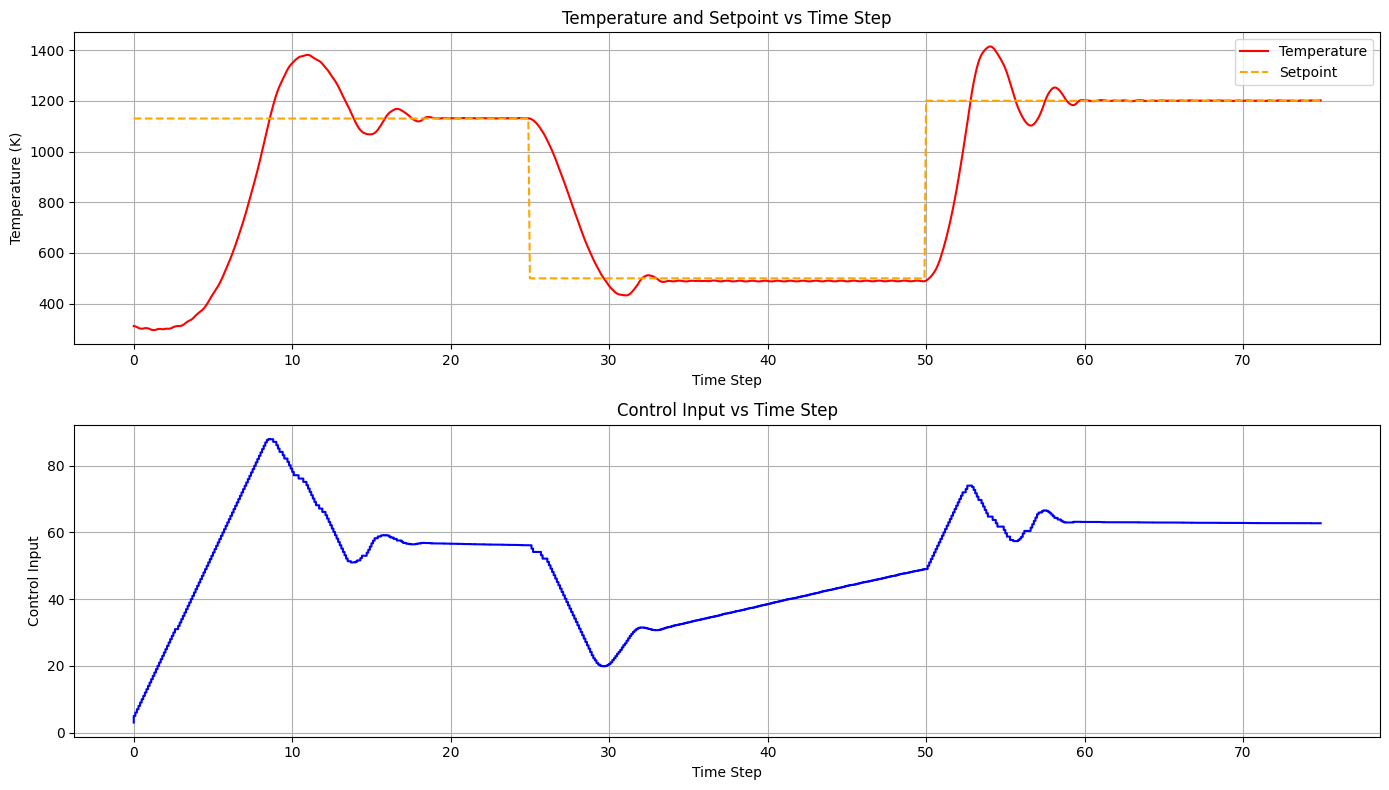

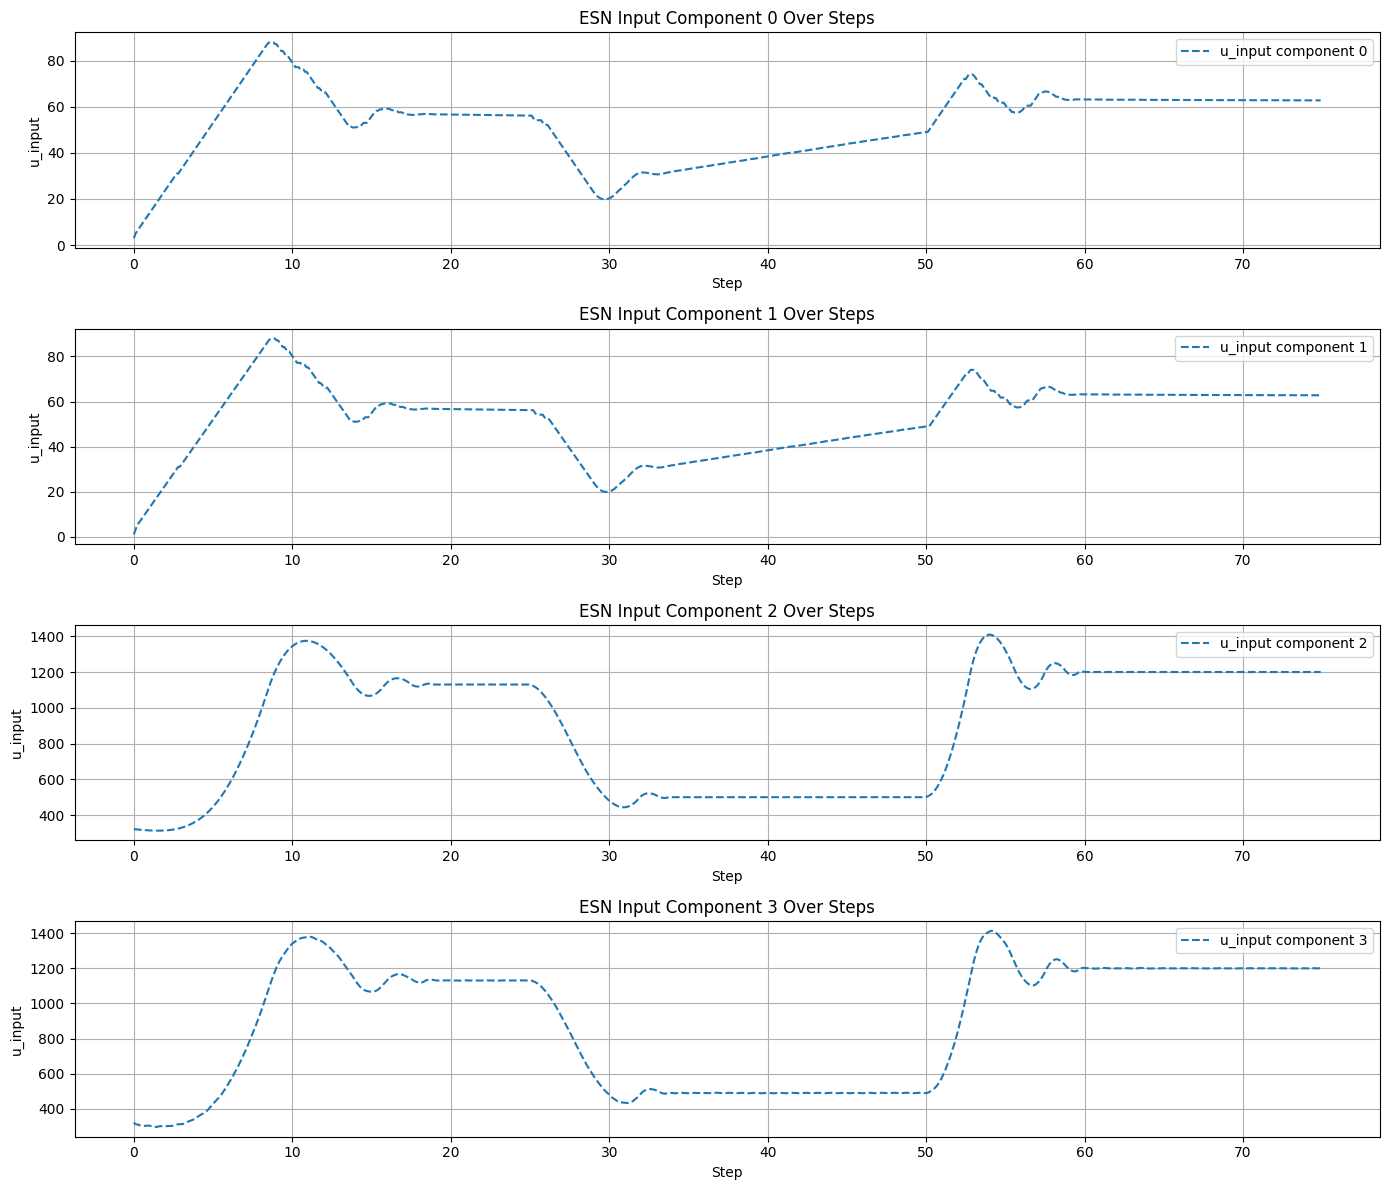

In [15]:
import os
import joblib
import numpy as np
from scipy.optimize import minimize
import copy
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------
# ESN-LSTM Online Prediction Model
# ---------------------------
class ManualESNLSTMOnline:
    def __init__(self, model_state_path, u_prev, y_lstm_scaled_prev_last):
        # Load saved model state (ensure keys exist!)
        self.model_state = joblib.load(model_state_path)
        self.esn_weights_history = self.model_state["esn_weights_history"]
        self.esn_states = self.model_state["esn_states"]
        self.esn_output_history = self.model_state["esn_output_history"]
        self.raw_input = self.model_state["raw_input"]
        self.scaler_X = self.model_state["scaler_X"]
        self.lstm_weights_history = self.model_state["lstm_weights_history"]
        self.lstm_hidden_states = self.model_state["lstm_hidden_states"]
        self.lstm_cell_states = self.model_state["lstm_cell_states"]
        self.lstm_output_history = self.model_state["lstm_output_history"]
        self.scaler_y = self.model_state.get("scaler_y")  # Ensure scaler_y exists!

        # Extract final dense layer weights from LSTM model
        lstm_dense = self.model_state["lstm_model"].layers[-1]
        self.W_d = lstm_dense.get_weights()[0]
        self.b_d = lstm_dense.get_weights()[1]

        # Initialize internal variables for LSTM state and control history
        self.u_prev = u_prev
        self.h_prev = np.zeros((1, self.W_d.shape[0]))
        self.c_prev = np.zeros((1, self.W_d.shape[0]))
        self.y_lstm_scaled_prev = [y_lstm_scaled_prev_last]  
        
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def tanh(self, x):
        return np.tanh(x)

    def forward_pass_esn(self, u_current, u_prev, y_lstm_scaled_prev, step):
        # Safe indexing: use the last available index if step exceeds length.
        index = min(step, len(self.esn_weights_history) - 1)
        params = self.esn_weights_history[index]
        W_in, W_res, W_out, W_fb, bias = (params["W_in"], params["W_res"],
                                          params["W_out"], params["W_fb"], params["bias"])

        u_prev = u_prev[0] if isinstance(u_prev, list) else u_prev
        if len(y_lstm_scaled_prev) > 0:
            y_lstm_scaled_prev_last = y_lstm_scaled_prev[-1]
        else:
            y_lstm_scaled_prev_last = 322

        #u_input = np.array([float(u_current), float(u_prev), float(y_lstm_scaled_prev_last)]).reshape(1, -1)
        u_input = np.array([float(u_current), float(u_prev), float(self.raw_input[step % len(self.raw_input)][2]), float(y_lstm_scaled_prev_last)]).reshape(1, -1)     # dipake pas inputnya 4
        u_scaled = self.scaler_X.transform(u_input).flatten()
        # Use safe indexing for previous state.
        prev_index = min(step - 1, len(self.esn_states) - 1)
        x_esn_prev = np.array(self.esn_states[prev_index][:50]).flatten()
        y_esn_prev = np.array(self.esn_output_history[prev_index]).flatten()
        pre_act = np.dot(W_in, u_scaled) + np.dot(W_res, x_esn_prev) + np.dot(W_fb, y_esn_prev) + bias
        x_extended = np.concatenate((pre_act, u_scaled, [bias]))
        y_esn_pred = np.dot(W_out, x_extended)[0]
        return y_esn_pred

    def forward_pass_lstm(self, y_esn_pred, step):
        # Safe indexing for LSTM weights:
        index = min(step, len(self.lstm_weights_history) - 1)
        snapshot = self.lstm_weights_history[index]
        kernel, recurrent_kernel, bias = snapshot[0], snapshot[1], snapshot[2]
        H = bias.shape[0] // 4
        W_i, W_f, W_c, W_o = (kernel[:, :H], kernel[:, H:2*H], kernel[:, 2*H:3*H], kernel[:, 3*H:])
        U_i, U_f, U_c, U_o = (recurrent_kernel[:, :H], recurrent_kernel[:, H:2*H],
                               recurrent_kernel[:, 2*H:3*H], recurrent_kernel[:, 3*H:])
        b_i, b_f, b_c, b_o = (bias[:H], bias[H:2*H], bias[2*H:3*H], bias[3*H:])
        x_t = np.array([[y_esn_pred]])
        h_prev = self.h_prev
        c_prev = self.c_prev
        i_t = self.sigmoid(np.dot(x_t, W_i) + np.dot(h_prev, U_i) + b_i)
        f_t = self.sigmoid(np.dot(x_t, W_f) + np.dot(h_prev, U_f) + b_f)
        o_t = self.sigmoid(np.dot(x_t, W_o) + np.dot(h_prev, U_o) + b_o)
        c_hat_t = self.tanh(np.dot(x_t, W_c) + np.dot(h_prev, U_c) + b_c)
        c_t = f_t * c_prev + i_t * c_hat_t
        h_t = o_t * self.tanh(c_t)
        
        y_t = np.dot(h_t, self.W_d) + self.b_d
        y_t_scalar = y_t.flatten()[0]
        y_t_scaled = self.scaler_y.inverse_transform(np.array([[y_t_scalar]]))[0][0]
        return y_t_scalar, y_t_scaled

    def run(self, u_current_value, step):  
        u_current = u_current_value
        # Proceed with the forward pass of ESN and LSTM
        y_esn_pred = self.forward_pass_esn(u_current, self.u_prev, self.y_lstm_scaled_prev, step)
        y_t_scalar, y_t_scaled = self.forward_pass_lstm(y_esn_pred, step)
        
        # Store the new control input as u_prev for the next step
        self.u_prev = u_current
        
        # Append the current prediction to the history for the next step
        self.y_lstm_scaled_prev.append(y_t_scaled)
        
        return {'Temperature (K)': y_t_scaled, 'y_esn_pred': y_esn_pred}

# ---------------------------
# MPC Controller Definition
# ---------------------------
class MPC:
    def __init__(self, config, esn_lstm_model):
        self.control_sequence = list(config["initial_control_sequence"])
        self.setpoints = config["setpoints"]
        self.total_steps = config["simulation_steps"]
        self.delta_u_max = config["delta_u_max"]
        self.u_min = config["u_min"]
        self.u_max = config["u_max"]
        self.R_weight = config["R_weight"]
        self.Q_weight = config["Q_weight"]
        self.u_prev = config["initial_control_sequence"][-1]
        self.prediction_horizon = config["prediction_horizon"]
        self.control_horizon = config["control_horizon"]
        self.model = esn_lstm_model

    def get_current_setpoint(self, current_global_step):
        # Divide the total simulation steps into contiguous sections based on the length of setpoints.
        num_sections = len(self.setpoints)
        section_length = self.total_steps / num_sections
        section_index = int(current_global_step / section_length)
        section_index = min(section_index, num_sections - 1)
        return self.setpoints[section_index]

    def simulate_horizon(self, u_seq, current_global_step):
        model_backup = copy.deepcopy(self.model)
        errors = []
        for m in range(self.prediction_horizon):
            u_m = u_seq[m] if m < len(u_seq) else u_seq[-1]
            out = model_backup.run(u_m, step=current_global_step + m)
            pred_temp = out['Temperature (K)']
            sp = self.get_current_setpoint(current_global_step + m)
            errors.append(pred_temp - sp)
        return errors

    def cost_function(self, u):
        u_seq = u 
        current_global_step = self.model.model_state.get("current_step", 0)
        errors = self.simulate_horizon(u_seq, current_global_step)
        tracking_cost = self.Q_weight * np.sum(np.array(errors) ** 2)
        control_moves = np.array([u_seq[0] - self.u_prev] + [u_seq[i] - u_seq[i - 1] for i in range(1, self.control_horizon)])
        R = self.R_weight * np.eye(self.control_horizon)
        control_cost = control_moves.T @ R @ control_moves
        return tracking_cost + control_cost

    def constraint1(self, u):
        return self.delta_u_max - (u[0] - self.u_prev)

    def constraint2(self, u):
        return self.delta_u_max - (self.u_prev - u[0])

    def solve(self):
        bounds = [(self.u_min, self.u_max)] * self.control_horizon
        cons = [{'type': 'ineq', 'fun': self.constraint1},
                {'type': 'ineq', 'fun': self.constraint2}]
        x0 = np.array([self.u_prev] * self.control_horizon)
        res = minimize(self.cost_function, x0, method='SLSQP', bounds=bounds, constraints=cons)
        if res.success:
            return res.x
        else:
            return x0

    def update(self, global_step):
        optimal_u_seq = self.solve()
        self.control_sequence.append(optimal_u_seq[0])
        self.u_prev = optimal_u_seq[0]
        out = self.model.run(optimal_u_seq[0], step=global_step)
        return out

# ---------------------------
# Main Function for Simulation and Plotting
# ---------------------------
def main(config):
    model_state_path = config["model_state_path"]
    esn_lstm_model = ManualESNLSTMOnline(model_state_path, config["u_prev"], config["y_lstm_scaled_prev_last"])
    
    mpc = MPC(config, esn_lstm_model)

    steps_list = []
    control_input_list = []
    output_list = []  
    setpoint_list = []
    u_input_0_list = []
    u_input_1_list = []
    u_input_2_list = []     
    u_input_3_list = []   # dipake pas inputnya 4

    for global_step in range(config["simulation_steps"]):
        current_setpoint = mpc.get_current_setpoint(global_step)
        out = mpc.update(global_step)
        temperature = out['Temperature (K)']
        
        # Capture u_input at this step
        if global_step == 0:
            control = mpc.control_sequence[0]
            u_prev = config["u_prev"]
            esn_lstm_model.u_prev = [u_prev]  
            y_lstm_scaled_prev_last = config["y_lstm_scaled_prev_last"]
            esn_lstm_model.y_lstm_scaled_prev = [y_lstm_scaled_prev_last] 
        else :
            control = mpc.control_sequence[-1]
            u_prev = control_input_list[-1]
            y_lstm_scaled_prev_last = output_list[-1]
            
        #u_input = np.array([float(control), float(u_prev), float(y_lstm_scaled_prev_last)]).reshape(1, -1)   
        u_input = np.array([float(control), float(u_prev), float(esn_lstm_model.raw_input[global_step % len(esn_lstm_model.raw_input)][2]), float(y_lstm_scaled_prev_last)]).reshape(1, -1)      # dipake pas inputnya 4

        # Store values individually
        steps_list.append(global_step * config["delta_t"])
        control_input_list.append(control)
        setpoint_list.append(current_setpoint)
        output_list.append(temperature)
        u_input_0_list.append(u_input[0, 0])
        u_input_1_list.append(u_input[0, 1])
        u_input_2_list.append(u_input[0, 2])
        u_input_3_list.append(u_input[0, 3])   # dipake pas inputnya 4

        # Check y_esn_pred at each step
        y_esn_pred = out['y_esn_pred']
        
        print(f"\nTime step {global_step}, Setpoint = {current_setpoint}")
        print(f"k-0 I0_control (A) = {u_input[0, 0]}")
        print(f"k-1 I0_control (A) = {u_input[0, 1]}")
        #print(f"k-1 Temperature (K) = {u_input[0, 2]}")    # dipake pas inputnya 3
        print(f"k-0 Temperature (K) = {u_input[0, 2]}")     # dipake pas inputnya 4
        print(f"k-1 Temperature (K) = {u_input[0, 3]}")     # dipake pas inputnya 4
        print(f"Temperature (K) = {temperature}")

        esn_lstm_model.u_prev = control
        esn_lstm_model.model_state["current_step"] = global_step

    # Save results to Excel
    save_file = config["save_file"]
    combined_df = pd.DataFrame({
        "Time (s)": steps_list,
        "k-0 I0_control (A)": u_input_0_list,
        "k-1 I0_control (A)": u_input_1_list,
        #"k-1 Temperature (K)": u_input_2_list,    # dipake pas inputnya 3
        "k-0 Temperature (K)": u_input_2_list,   # dipake pas inputnya 4
        "k-1 Temperature (K)": u_input_3_list,   # dipake pas inputnya 4
        "Temperature (K)": output_list,
        "setpoint": setpoint_list
    })

    directory = os.path.dirname(config["model_state_path"])
    excel_filename = os.path.join(directory, f"{config['code_name']}_MPC_ESN_LSTM_results.xlsx")
    with pd.ExcelWriter(excel_filename, engine="xlsxwriter") as writer:
        combined_df.to_excel(writer, sheet_name="results", index=False)
    print(f"Simulation data saved to {excel_filename}")

    # Plot Temperature and Setpoint vs Time Step
    plt.figure(figsize=(14, 8))
    plt.subplot(2,1,1)
    plt.plot(steps_list, output_list, linestyle='-', color='red', label='Temperature')
    plt.plot(steps_list, setpoint_list, linestyle='--', color='orange', label='Setpoint')
    plt.xlabel("Time Step")
    plt.ylabel("Temperature (K)")
    plt.title("Temperature and Setpoint vs Time Step")
    plt.legend()
    plt.grid(True)

    # Plot Control Input vs Time Step
    plt.subplot(2,1,2)
    plt.step(steps_list, control_input_list, linestyle='-', color='blue', label='I0 Control (A)')
    plt.xlabel("Time Step")
    plt.ylabel("Control Input")
    plt.title("Control Input vs Time Step")
    plt.grid(True)
    plt.tight_layout()
    control_fig_file = os.path.join(save_file, f"{config['code_name']}_mpc_esn_lstm_Control_Input_of_temperature_vs_Time.png")
    plt.savefig(control_fig_file)
    plt.show()

    #u_input_arr = np.column_stack((u_input_0_list, u_input_1_list, u_input_2_list))                    # dipake pas inputnya 3
    u_input_arr = np.column_stack((u_input_0_list, u_input_1_list, u_input_2_list, u_input_3_list))    # dipake pas inputnya 4
    
    # Create subplots for each component
    fig, axes = plt.subplots(u_input_arr.shape[1], 1, figsize=(14, 12))
    
    # Plot each component separately on its own subplot
    for i in range(u_input_arr.shape[1]):
        axes[i].plot(steps_list, u_input_arr[:, i], label=f"u_input component {i}", linestyle='--')
        axes[i].set_xlabel("Step")
        axes[i].set_ylabel("u_input")
        axes[i].set_title(f"ESN Input Component {i} Over Steps")
        axes[i].grid(True)
        axes[i].legend()
    
    plt.tight_layout()
    u_input_fig_file = os.path.join(save_file, f"{config['code_name']}_mpc_esn_lstm_u_input_components.png")
    plt.savefig(u_input_fig_file)
    plt.show()

if __name__ == "__main__":
    config = {
        "code_name" : "4_input",
        "model_state_path": r"D:\Python-Github-Projects\Model\4_input_MPC_ESN_LSTM_online_fullstate.pkl",
        "setpoints": [1130, 500, 1200],
        "initial_control_sequence": [3], 
        "u_prev": 1,  
        "y_lstm_scaled_prev_last": 322,
        "delta_u_max": 1,
        "u_min": 0.01,
        "u_max": 130,
        "R_weight": 1,
        "Q_weight": 1000, #100
        "delta_t": 0.1,
        "simulation_steps": 750,
        "prediction_horizon": 1,
        "control_horizon": 1,
        "save_file": r"D:\Python-Github-Projects\Model",
    }

    main(config)


